# Optimizers for Deep Learning: From Zero to Hero

## A Comprehensive, Beginner-Friendly Guide

---

**Welcome!** This notebook will take you on a journey through the fascinating world of optimization in deep learning. By the end, you'll understand:

- Why optimization is the **heart** of deep learning
- How gradient descent works (with beautiful visualizations)
- The problems with naive approaches and how to solve them
- Modern optimizers like Adam, AdamW, and beyond
- How to choose the right optimizer for your task

---

### Table of Contents

| Part | Topic | Key Concepts |
|------|-------|-------------|
| I | Introduction | Why optimizers matter, loss landscapes |
| II | Gradient Descent Basics | Gradients, learning rate, convergence |
| III | Problems with Vanilla GD | Saddle points, local minima, oscillations |
| IV | Stochastic Gradient Descent | Mini-batches, noise as a feature |
| V | Momentum Methods | Physics intuition, NAG |
| VI | Adaptive Learning Rates | AdaGrad, RMSprop |
| VII | Adam Family | Adam, AdamW, variants |
| VIII | Learning Rate Schedules | Warmup, cosine annealing, one-cycle |
| IX | Practical Comparisons | Real neural network training |
| X | Modern & Advanced | SAM, Lion, LARS, second-order |

---

### Prerequisites
- Basic Python knowledge
- High school calculus (we'll explain everything gently!)
- Curiosity about how neural networks learn

Let's begin!


In [ ]:
# Install dependencies (run this cell first!)
!pip install -q numpy matplotlib torch torchvision scikit-learn

In [ ]:
# Import libraries
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.colors import LinearSegmentedColormap
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.patches as mpatches
from matplotlib.animation import FuncAnimation
from IPython.display import HTML, display
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.datasets import make_moons, make_classification
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)

# Set plot style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['axes.titlesize'] = 16

print("All libraries loaded successfully!")
print(f"PyTorch version: {torch.__version__}")

All libraries loaded successfully!
PyTorch version: 2.10.0+cpu


---

# Part I: Introduction - Why Optimizers Matter

---

## 1.1 The Central Problem of Deep Learning

At its core, deep learning is about finding the **best parameters** (weights and biases) for a neural network. But what does "best" mean?

### The Learning Process

```
     INPUT              NEURAL NETWORK              OUTPUT           LOSS
   (Images,       -->   (With learnable    -->   (Predictions)  --> (How wrong
    Text, etc.)          parameters W)                               are we?)
                              ^
                              |
                    OPTIMIZER UPDATES W
                    TO MINIMIZE LOSS!
```

**The Goal**: Find parameters W that minimize the loss function L(W)

This is an **optimization problem**!


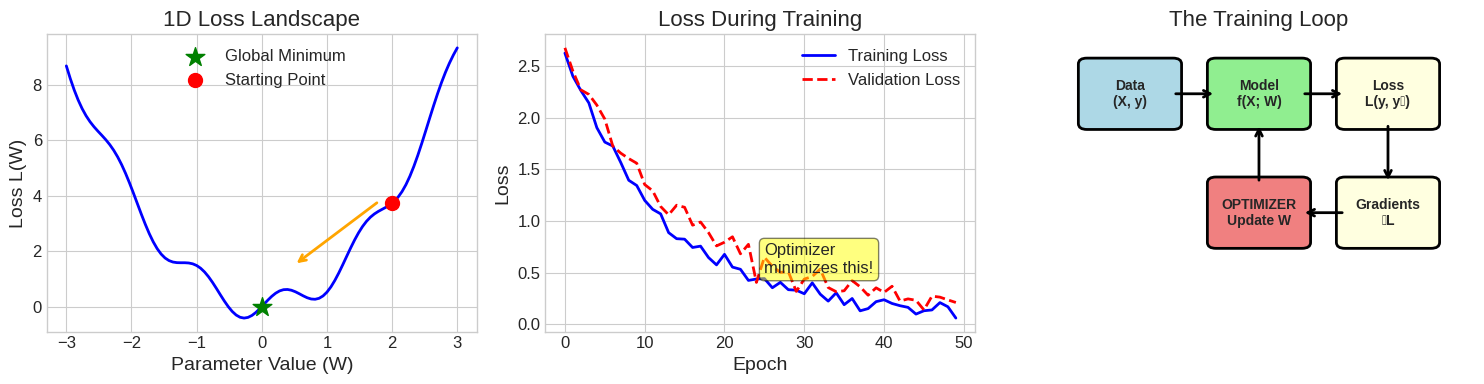


KEY INSIGHT: The optimizer is the ENGINE of learning!
It decides HOW to update parameters to reduce loss.


In [ ]:
# Visualization: The Optimization Journey
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Panel 1: Simple 1D loss landscape
x = np.linspace(-3, 3, 100)
loss = x**2 + 0.5 * np.sin(5*x)
axes[0].plot(x, loss, 'b-', linewidth=2)
axes[0].scatter([0], [0.5 * np.sin(0)], color='green', s=200, zorder=5,
                marker='*', label='Global Minimum')
axes[0].scatter([2], [4 + 0.5*np.sin(10)], color='red', s=100, zorder=5,
                marker='o', label='Starting Point')
axes[0].annotate('', xy=(0.5, 1.5), xytext=(1.8, 3.8),
                 arrowprops=dict(arrowstyle='->', color='orange', lw=2))
axes[0].set_xlabel('Parameter Value (W)')
axes[0].set_ylabel('Loss L(W)')
axes[0].set_title('1D Loss Landscape')
axes[0].legend()

# Panel 2: Training process illustration
epochs = np.arange(0, 50)
training_loss = 2.5 * np.exp(-0.08 * epochs) + 0.1 + 0.05 * np.random.randn(50)
val_loss = 2.5 * np.exp(-0.07 * epochs) + 0.15 + 0.08 * np.random.randn(50)
axes[1].plot(epochs, training_loss, 'b-', linewidth=2, label='Training Loss')
axes[1].plot(epochs, val_loss, 'r--', linewidth=2, label='Validation Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].set_title('Loss During Training')
axes[1].legend()
axes[1].annotate('Optimizer\nminimizes this!', xy=(25, 0.5), fontsize=12,
                 bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.5))

# Panel 3: The role of optimizer
axes[2].axis('off')
boxes = [
    {'xy': (0.1, 0.7), 'text': 'Data\n(X, y)', 'color': 'lightblue'},
    {'xy': (0.4, 0.7), 'text': 'Model\nf(X; W)', 'color': 'lightgreen'},
    {'xy': (0.7, 0.7), 'text': 'Loss\nL(y, y\u0302)', 'color': 'lightyellow'},
    {'xy': (0.7, 0.3), 'text': 'Gradients\n\u2207L', 'color': 'lightyellow'},
    {'xy': (0.4, 0.3), 'text': 'OPTIMIZER\nUpdate W', 'color': 'lightcoral'},
]
for box in boxes:
    rect = mpatches.FancyBboxPatch(box['xy'], 0.2, 0.2,
                                    boxstyle='round,pad=0.02',
                                    facecolor=box['color'],
                                    edgecolor='black', linewidth=2)
    axes[2].add_patch(rect)
    axes[2].text(box['xy'][0] + 0.1, box['xy'][1] + 0.1, box['text'],
                 ha='center', va='center', fontsize=10, fontweight='bold')

# Arrows
arrows = [
    ((0.3, 0.8), (0.4, 0.8)),   # Data -> Model
    ((0.6, 0.8), (0.7, 0.8)),   # Model -> Loss
    ((0.8, 0.7), (0.8, 0.5)),   # Loss -> Gradients
    ((0.7, 0.4), (0.6, 0.4)),   # Gradients -> Optimizer
    ((0.5, 0.5), (0.5, 0.7)),   # Optimizer -> Model
]
for start, end in arrows:
    axes[2].annotate('', xy=end, xytext=start,
                     arrowprops=dict(arrowstyle='->', color='black', lw=2))
axes[2].set_xlim(0, 1)
axes[2].set_ylim(0, 1)
axes[2].set_title('The Training Loop')

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("KEY INSIGHT: The optimizer is the ENGINE of learning!")
print("It decides HOW to update parameters to reduce loss.")
print("="*60)

## 1.2 What is a Loss Landscape?

Imagine your neural network has millions of parameters. The **loss landscape** is a surface where:
- Each point represents a specific set of parameters
- The height at that point is the loss (error) for those parameters

**Our goal**: Find the lowest point (minimum loss)!

### Analogy: Finding the Lowest Valley

Think of yourself as a hiker in the mountains (but blindfolded!):
- You can only feel the slope right under your feet
- You want to reach the lowest valley
- The optimizer is your strategy for deciding which way to step

Let's visualize a 2D loss landscape (imagine this but with millions of dimensions!):


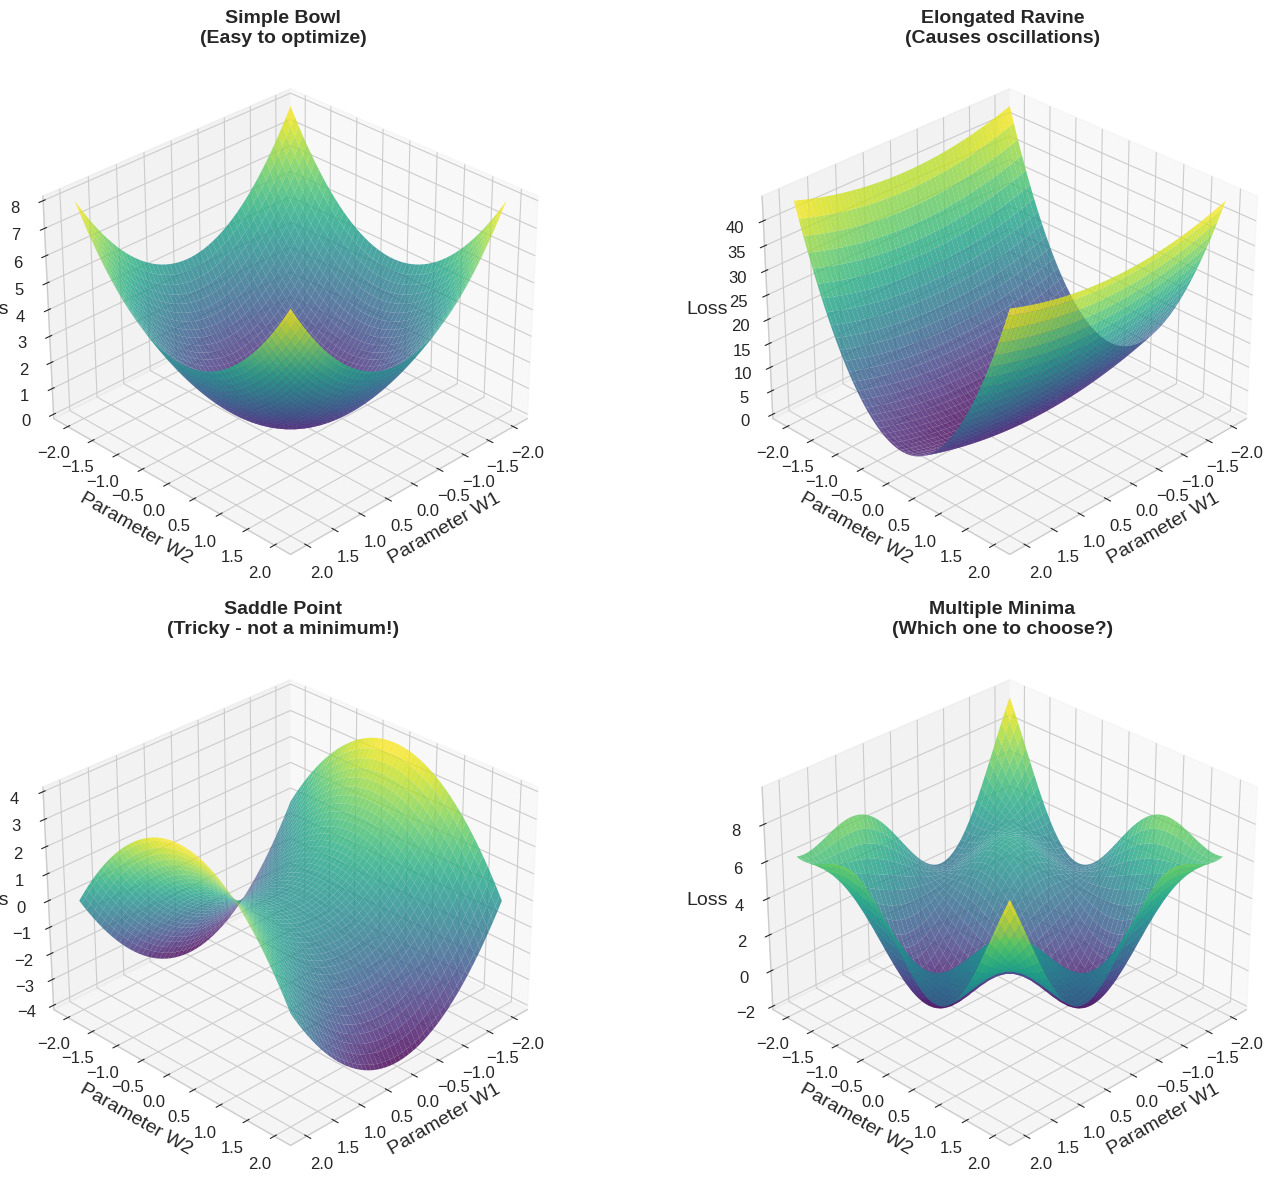


REAL NEURAL NETWORKS have landscapes with MILLIONS of dimensions!
Different optimizers handle these challenges differently.


In [ ]:
# Create a beautiful 2D loss landscape visualization
def create_loss_landscape(x, y, landscape_type='simple'):
    """Generate different types of loss landscapes for visualization."""
    if landscape_type == 'simple':
        # Simple bowl - easy to optimize
        return x**2 + y**2
    elif landscape_type == 'ravine':
        # Elongated ravine - causes oscillations
        return x**2 + 10*y**2
    elif landscape_type == 'saddle':
        # Saddle point - tricky for optimizers
        return x**2 - y**2
    elif landscape_type == 'multimodal':
        # Multiple local minima - realistic scenario
        return (x**2 + y**2) + 3*np.sin(2*x)*np.sin(2*y)
    elif landscape_type == 'realistic':
        # More realistic deep learning landscape
        return (1 - x)**2 + 100*(y - x**2)**2  # Rosenbrock function

# Create meshgrid
x_range = np.linspace(-2, 2, 100)
y_range = np.linspace(-2, 2, 100)
X, Y = np.meshgrid(x_range, y_range)

# Create figure with multiple landscape types
fig = plt.figure(figsize=(16, 12))

landscapes = [
    ('simple', 'Simple Bowl\n(Easy to optimize)', (-2, 2)),
    ('ravine', 'Elongated Ravine\n(Causes oscillations)', (-2, 2)),
    ('saddle', 'Saddle Point\n(Tricky - not a minimum!)', (-2, 2)),
    ('multimodal', 'Multiple Minima\n(Which one to choose?)', (-2, 2)),
]

for idx, (ltype, title, _) in enumerate(landscapes):
    ax = fig.add_subplot(2, 2, idx + 1, projection='3d')
    Z = create_loss_landscape(X, Y, ltype)

    # Create surface plot
    surf = ax.plot_surface(X, Y, Z, cmap='viridis', alpha=0.8,
                           linewidth=0, antialiased=True)

    ax.set_xlabel('Parameter W1')
    ax.set_ylabel('Parameter W2')
    ax.set_zlabel('Loss')
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.view_init(elev=30, azim=45)

plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("REAL NEURAL NETWORKS have landscapes with MILLIONS of dimensions!")
print("Different optimizers handle these challenges differently.")
print("="*70)

## 1.3 Contour Plots: A Bird's Eye View

**Contour plots** show loss landscapes from above, like a topographic map:
- Lines connect points of equal loss
- Closer lines = steeper slope
- The center (darkest) is usually the minimum

This view is essential for understanding how different optimizers navigate!


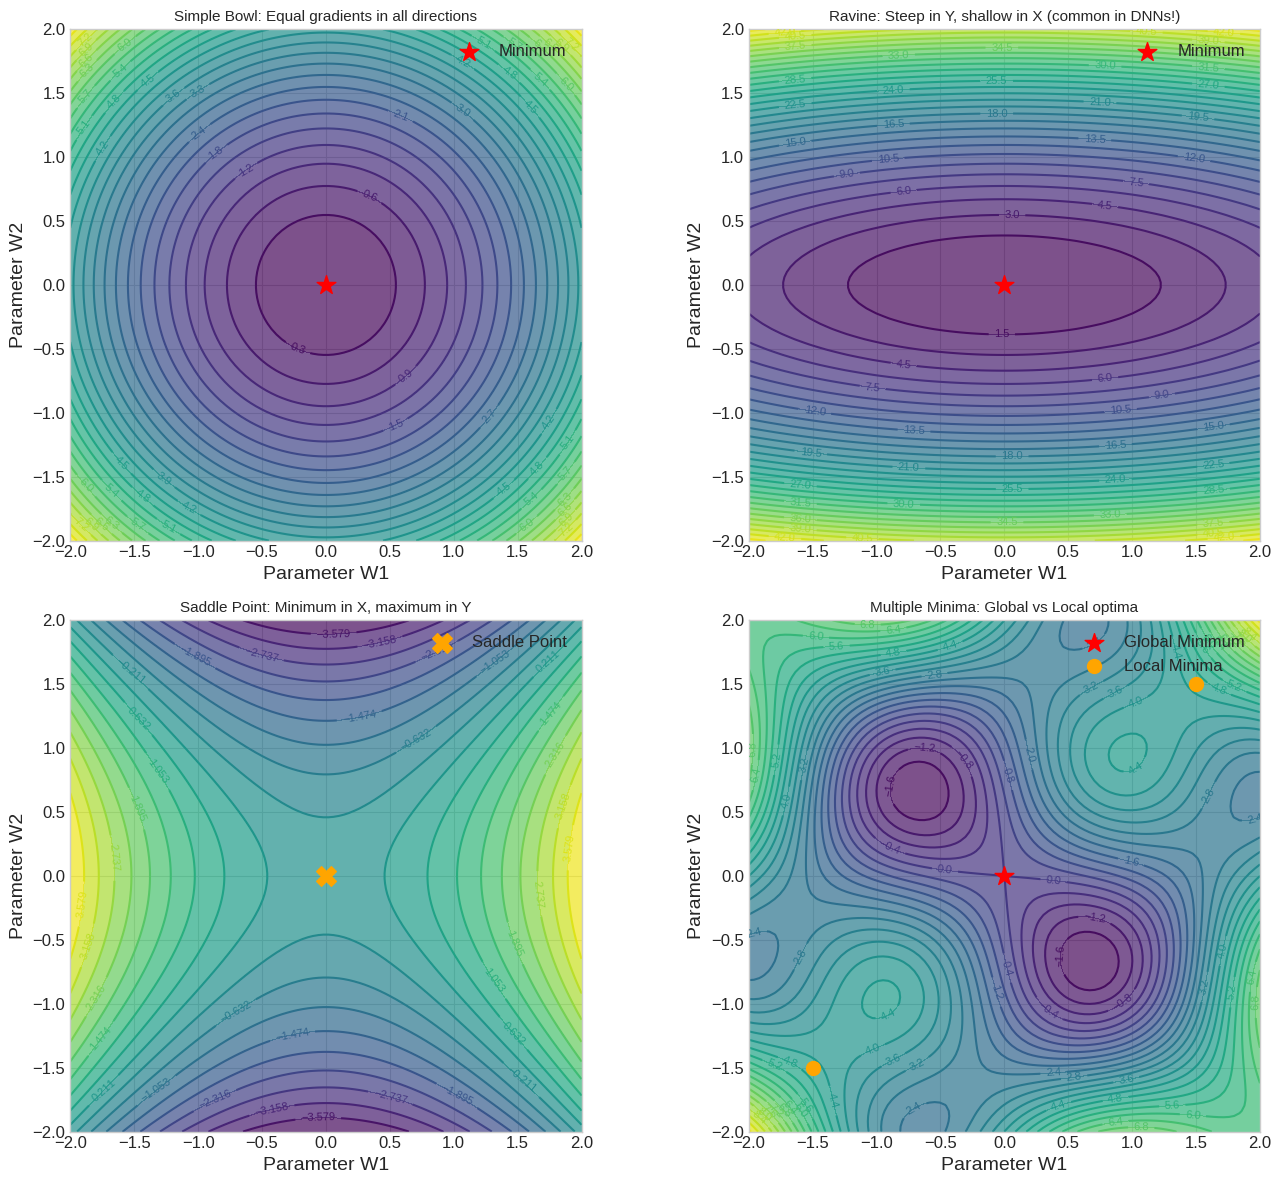

In [ ]:
# Contour plot visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

landscapes = ['simple', 'ravine', 'saddle', 'multimodal']
titles = [
    'Simple Bowl: Equal gradients in all directions',
    'Ravine: Steep in Y, shallow in X (common in DNNs!)',
    'Saddle Point: Minimum in X, maximum in Y',
    'Multiple Minima: Global vs Local optima'
]

for ax, ltype, title in zip(axes.flat, landscapes, titles):
    Z = create_loss_landscape(X, Y, ltype)

    # Contour plot
    if ltype == 'saddle':
        levels = np.linspace(-4, 4, 20)
    else:
        levels = 30

    contour = ax.contour(X, Y, Z, levels=levels, cmap='viridis')
    ax.contourf(X, Y, Z, levels=levels, cmap='viridis', alpha=0.7)
    ax.clabel(contour, inline=True, fontsize=8)

    # Mark the minimum (or saddle point)
    if ltype in ['simple', 'ravine']:
        ax.scatter([0], [0], color='red', s=200, marker='*',
                   zorder=5, label='Minimum')
    elif ltype == 'saddle':
        ax.scatter([0], [0], color='orange', s=200, marker='X',
                   zorder=5, label='Saddle Point')
    else:  # multimodal
        # Find approximate minima
        ax.scatter([0], [0], color='red', s=200, marker='*',
                   zorder=5, label='Global Minimum')
        ax.scatter([1.5, -1.5], [1.5, -1.5], color='orange', s=100,
                   marker='o', zorder=5, label='Local Minima')

    ax.set_xlabel('Parameter W1')
    ax.set_ylabel('Parameter W2')
    ax.set_title(title, fontsize=11)
    ax.legend(loc='upper right')
    ax.set_aspect('equal')

plt.tight_layout()
plt.show()

## 1.4 Why Deep Learning Optimization is Hard

Real neural network loss landscapes have several challenges:

| Challenge | Description | Impact |
|-----------|-------------|--------|
| **High Dimensionality** | Millions of parameters | Hard to visualize and navigate |
| **Non-Convexity** | Multiple local minima | May get stuck in suboptimal solutions |
| **Saddle Points** | Flat regions with zero gradient | Optimization can stall |
| **Ill-Conditioning** | Different curvatures in different directions | Oscillations, slow convergence |
| **Noise** | Stochastic gradients from mini-batches | Noisy updates |
| **Vanishing/Exploding Gradients** | Gradients become too small/large | Training fails completely |

**Good news**: Modern optimizers are designed to handle these challenges!


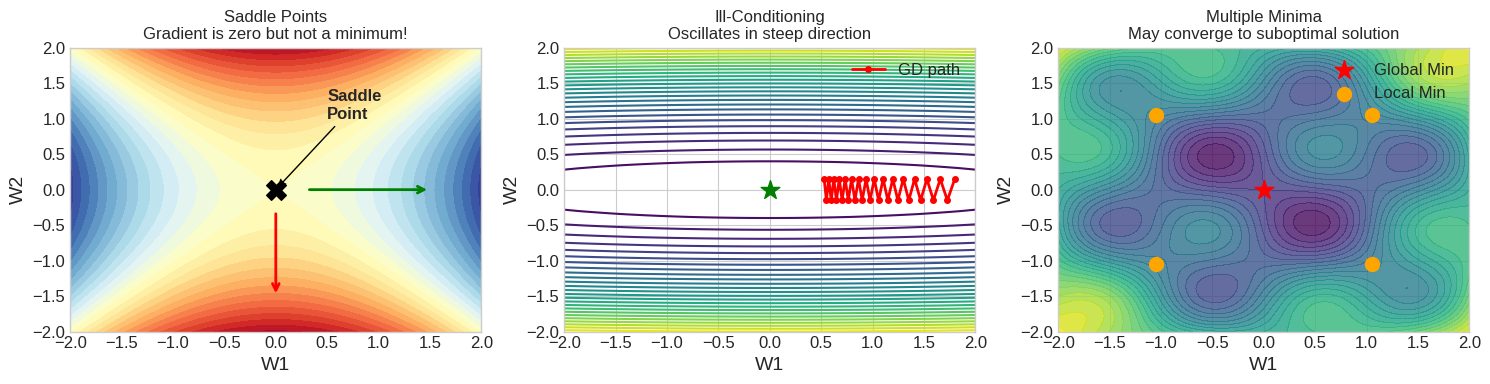


These challenges motivated the development of better optimizers!
Let's see how gradient descent works and then improve it.


In [ ]:
# Visualize the challenges
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Challenge 1: Saddle points (common in high dimensions)
ax = axes[0]
x = np.linspace(-2, 2, 100)
y = np.linspace(-2, 2, 100)
X_s, Y_s = np.meshgrid(x, y)
Z_saddle = X_s**2 - Y_s**2
ax.contourf(X_s, Y_s, Z_saddle, levels=30, cmap='RdYlBu')
ax.scatter([0], [0], color='black', s=200, marker='X', zorder=5)
ax.annotate('Saddle\nPoint', xy=(0, 0), xytext=(0.5, 1),
            fontsize=12, fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='black'))
# Draw gradient directions
ax.annotate('', xy=(1.5, 0), xytext=(0.3, 0),
            arrowprops=dict(arrowstyle='->', color='green', lw=2))
ax.annotate('', xy=(0, -1.5), xytext=(0, -0.3),
            arrowprops=dict(arrowstyle='->', color='red', lw=2))
ax.set_title('Saddle Points\nGradient is zero but not a minimum!', fontsize=12)
ax.set_xlabel('W1')
ax.set_ylabel('W2')

# Challenge 2: Ill-conditioning (different curvatures)
ax = axes[1]
Z_ravine = X_s**2 + 50*Y_s**2
ax.contour(X_s, Y_s, Z_ravine, levels=30, cmap='viridis')
# Simulate gradient descent path with oscillations
path_x = [1.8]
path_y = [0.15]
lr = 0.02
for _ in range(30):
    grad_x = 2 * path_x[-1]
    grad_y = 100 * path_y[-1]
    path_x.append(path_x[-1] - lr * grad_x)
    path_y.append(path_y[-1] - lr * grad_y)
ax.plot(path_x, path_y, 'r.-', linewidth=2, markersize=8, label='GD path')
ax.scatter([0], [0], color='green', s=200, marker='*', zorder=5)
ax.set_title('Ill-Conditioning\nOscillates in steep direction', fontsize=12)
ax.set_xlabel('W1')
ax.set_ylabel('W2')
ax.legend()

# Challenge 3: Local minima
ax = axes[2]
Z_multi = (X_s**2 + Y_s**2) + 2*np.sin(3*X_s)*np.sin(3*Y_s)
ax.contourf(X_s, Y_s, Z_multi, levels=30, cmap='viridis', alpha=0.8)
ax.scatter([0], [0], color='red', s=200, marker='*',
           zorder=5, label='Global Min')
ax.scatter([1.05, -1.05, 1.05, -1.05], [1.05, 1.05, -1.05, -1.05],
           color='orange', s=100, marker='o', zorder=5, label='Local Min')
ax.set_title('Multiple Minima\nMay converge to suboptimal solution', fontsize=12)
ax.set_xlabel('W1')
ax.set_ylabel('W2')
ax.legend()

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("These challenges motivated the development of better optimizers!")
print("Let's see how gradient descent works and then improve it.")
print("="*60)

---

# Part II: Gradient Descent Fundamentals

---

## 2.1 What is a Gradient?

The **gradient** is a vector that points in the direction of **steepest increase** of a function.

### Intuition

Imagine standing on a hillside:
- The gradient tells you which direction is **steepest uphill**
- To go **downhill** (minimize loss), we go in the **opposite direction** of the gradient
- The **magnitude** tells us how steep the slope is

### Mathematical Definition

For a function $L(W)$ where $W = [w_1, w_2, ..., w_n]$:

$$\nabla L = \left[ \frac{\partial L}{\partial w_1}, \frac{\partial L}{\partial w_2}, ..., \frac{\partial L}{\partial w_n} \right]$$

Each partial derivative tells us: "If I nudge this parameter slightly, how much does the loss change?"


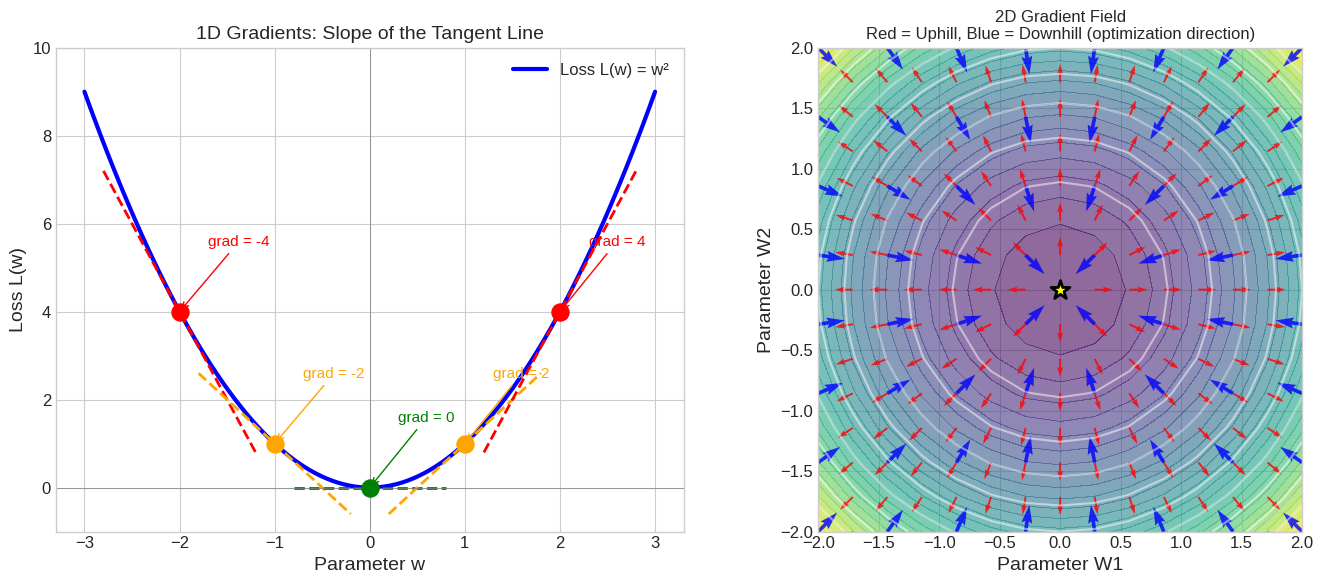


KEY INSIGHT: We move in the NEGATIVE gradient direction!
This takes us downhill toward lower loss.


In [ ]:
# Visualizing gradients
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 1D gradient visualization
ax = axes[0]
x = np.linspace(-3, 3, 100)
y = x**2  # Simple parabola
ax.plot(x, y, 'b-', linewidth=3, label='Loss L(w) = w²')

# Show gradient at different points
points = [-2, -1, 0, 1, 2]
colors = ['red', 'orange', 'green', 'orange', 'red']
for p, c in zip(points, colors):
    y_p = p**2
    grad = 2 * p  # derivative of x^2
    ax.scatter([p], [y_p], color=c, s=150, zorder=5)
    # Draw tangent line
    x_tan = np.linspace(p-0.8, p+0.8, 50)
    y_tan = y_p + grad * (x_tan - p)
    ax.plot(x_tan, y_tan, '--', color=c, linewidth=2)
    # Annotate gradient
    ax.annotate(f'grad = {grad}', xy=(p, y_p), xytext=(p+0.3, y_p+1.5),
                fontsize=11, color=c,
                arrowprops=dict(arrowstyle='->', color=c))

ax.axhline(y=0, color='gray', linestyle='-', linewidth=0.5)
ax.axvline(x=0, color='gray', linestyle='-', linewidth=0.5)
ax.set_xlabel('Parameter w')
ax.set_ylabel('Loss L(w)')
ax.set_title('1D Gradients: Slope of the Tangent Line', fontsize=14)
ax.legend()
ax.set_ylim(-1, 10)

# 2D gradient field visualization
ax = axes[1]
x = np.linspace(-2, 2, 15)
y = np.linspace(-2, 2, 15)
X_g, Y_g = np.meshgrid(x, y)
Z_g = X_g**2 + Y_g**2

# Compute gradients
grad_x = 2 * X_g  # dL/dw1
grad_y = 2 * Y_g  # dL/dw2

# Normalize for visualization
magnitude = np.sqrt(grad_x**2 + grad_y**2)
magnitude[magnitude == 0] = 1
grad_x_norm = grad_x / magnitude
grad_y_norm = grad_y / magnitude

# Contour plot
ax.contourf(X_g, Y_g, Z_g, levels=30, cmap='viridis', alpha=0.6)
ax.contour(X_g, Y_g, Z_g, levels=10, colors='white', alpha=0.5)

# Gradient arrows (pointing UPHILL)
ax.quiver(X_g, Y_g, grad_x_norm, grad_y_norm, color='red', alpha=0.8,
          label='Gradient (uphill)')

# Negative gradient arrows (pointing DOWNHILL)
ax.quiver(X_g[::2, ::2], Y_g[::2, ::2],
          -grad_x_norm[::2, ::2], -grad_y_norm[::2, ::2],
          color='blue', alpha=0.8, label='-Gradient (downhill)')

ax.scatter([0], [0], color='yellow', s=200, marker='*',
           zorder=5, edgecolor='black', linewidth=2)
ax.set_xlabel('Parameter W1')
ax.set_ylabel('Parameter W2')
ax.set_title('2D Gradient Field\nRed = Uphill, Blue = Downhill (optimization direction)',
             fontsize=12)
ax.set_aspect('equal')

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("KEY INSIGHT: We move in the NEGATIVE gradient direction!")
print("This takes us downhill toward lower loss.")
print("="*60)

## 2.2 Vanilla Gradient Descent

The simplest optimization algorithm:

$$W_{new} = W_{old} - \eta \cdot \nabla L(W_{old})$$

Where:
- $W$ = parameters (weights)
- $\eta$ (eta) = **learning rate** (how big a step to take)
- $\nabla L$ = gradient of the loss

### The Algorithm

```
1. Initialize parameters W randomly
2. Repeat until converged:
   a. Compute loss L(W)
   b. Compute gradient ∇L(W)
   c. Update: W = W - η * ∇L(W)
```


In [ ]:
# Implementation of vanilla gradient descent
class VanillaGradientDescent:
    """Simple gradient descent optimizer."""

    def __init__(self, learning_rate=0.1):
        self.lr = learning_rate
        self.history = []  # Track path for visualization

    def optimize(self, loss_fn, grad_fn, w_init, n_steps=50):
        """
        Optimize using gradient descent.

        Args:
            loss_fn: Function that computes loss given parameters
            grad_fn: Function that computes gradient given parameters
            w_init: Initial parameters (numpy array)
            n_steps: Number of optimization steps

        Returns:
            Final parameters
        """
        w = w_init.copy()
        self.history = [w.copy()]

        for _ in range(n_steps):
            grad = grad_fn(w)
            w = w - self.lr * grad  # The key update!
            self.history.append(w.copy())

        return w

# Define a simple loss function: L(w1, w2) = w1^2 + w2^2
def simple_loss(w):
    return w[0]**2 + w[1]**2

def simple_grad(w):
    return np.array([2*w[0], 2*w[1]])

# Run gradient descent
optimizer = VanillaGradientDescent(learning_rate=0.2)
w_init = np.array([2.0, 2.0])
w_final = optimizer.optimize(simple_loss, simple_grad, w_init, n_steps=20)

print(f"Starting point: {w_init}")
print(f"Final point: {w_final}")
print(f"Initial loss: {simple_loss(w_init):.4f}")
print(f"Final loss: {simple_loss(w_final):.4f}")

Starting point: [2. 2.]
Final point: [7.31231688e-05 7.31231688e-05]
Initial loss: 8.0000
Final loss: 0.0000


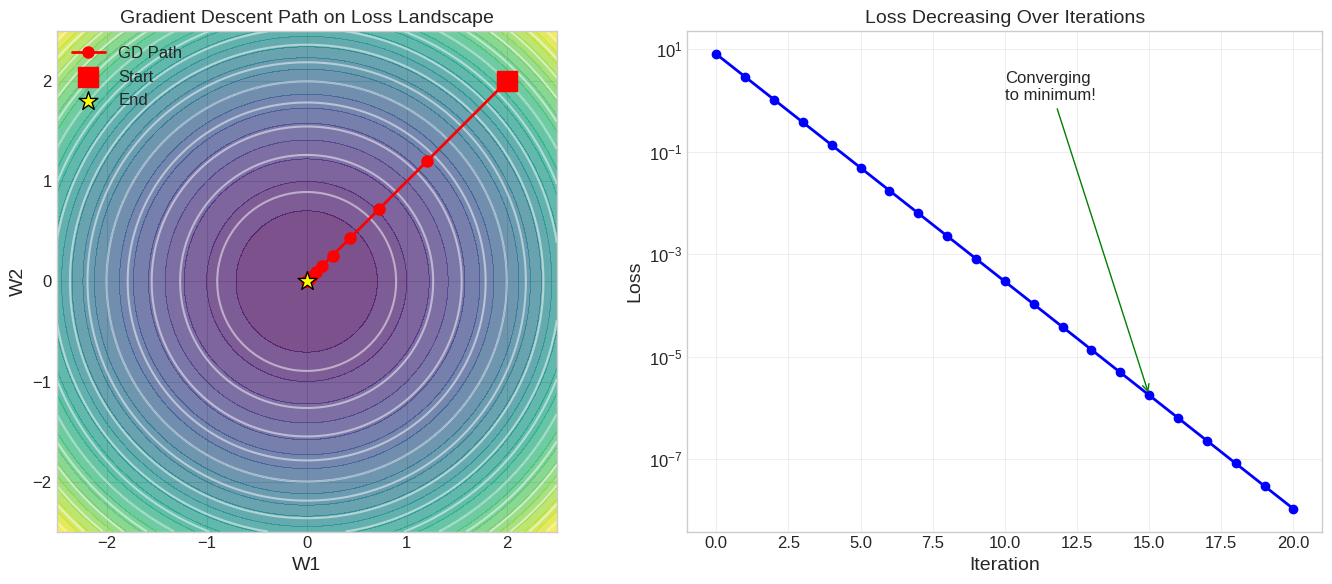

In [ ]:
# Visualize gradient descent path
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Contour with path
ax = axes[0]
x = np.linspace(-2.5, 2.5, 100)
y = np.linspace(-2.5, 2.5, 100)
X_p, Y_p = np.meshgrid(x, y)
Z_p = X_p**2 + Y_p**2

ax.contourf(X_p, Y_p, Z_p, levels=30, cmap='viridis', alpha=0.7)
ax.contour(X_p, Y_p, Z_p, levels=15, colors='white', alpha=0.5)

# Plot the path
history = np.array(optimizer.history)
ax.plot(history[:, 0], history[:, 1], 'ro-', markersize=8,
        linewidth=2, label='GD Path')
ax.scatter([history[0, 0]], [history[0, 1]], color='red', s=200,
           marker='s', zorder=5, label='Start')
ax.scatter([history[-1, 0]], [history[-1, 1]], color='yellow', s=200,
           marker='*', zorder=5, edgecolor='black', label='End')

ax.set_xlabel('W1')
ax.set_ylabel('W2')
ax.set_title('Gradient Descent Path on Loss Landscape', fontsize=14)
ax.legend()
ax.set_aspect('equal')

# Plot 2: Loss over iterations
ax = axes[1]
losses = [simple_loss(w) for w in history]
ax.plot(losses, 'b-o', linewidth=2, markersize=6)
ax.set_xlabel('Iteration')
ax.set_ylabel('Loss')
ax.set_title('Loss Decreasing Over Iterations', fontsize=14)
ax.set_yscale('log')
ax.grid(True, alpha=0.3)

# Annotate convergence
ax.annotate('Converging\nto minimum!', xy=(15, losses[15]),
            xytext=(10, 1),
            fontsize=12, arrowprops=dict(arrowstyle='->', color='green'))

plt.tight_layout()
plt.show()

## 2.3 The Learning Rate: The Most Important Hyperparameter

The **learning rate** ($\eta$) controls how big each step is:

| Learning Rate | Effect | Symptom |
|--------------|--------|----------|
| **Too small** | Takes forever to converge | Very slow progress |
| **Just right** | Efficient convergence | Smooth decrease in loss |
| **Too large** | Overshoots, may diverge | Loss oscillates or explodes |

### Visual Intuition

Think of learning rate as your **step size** when walking down a hill:
- **Too small**: You'll get there, but it takes thousands of tiny steps
- **Just right**: Efficient progress toward the bottom
- **Too large**: You jump over the valley and end up on the other side!


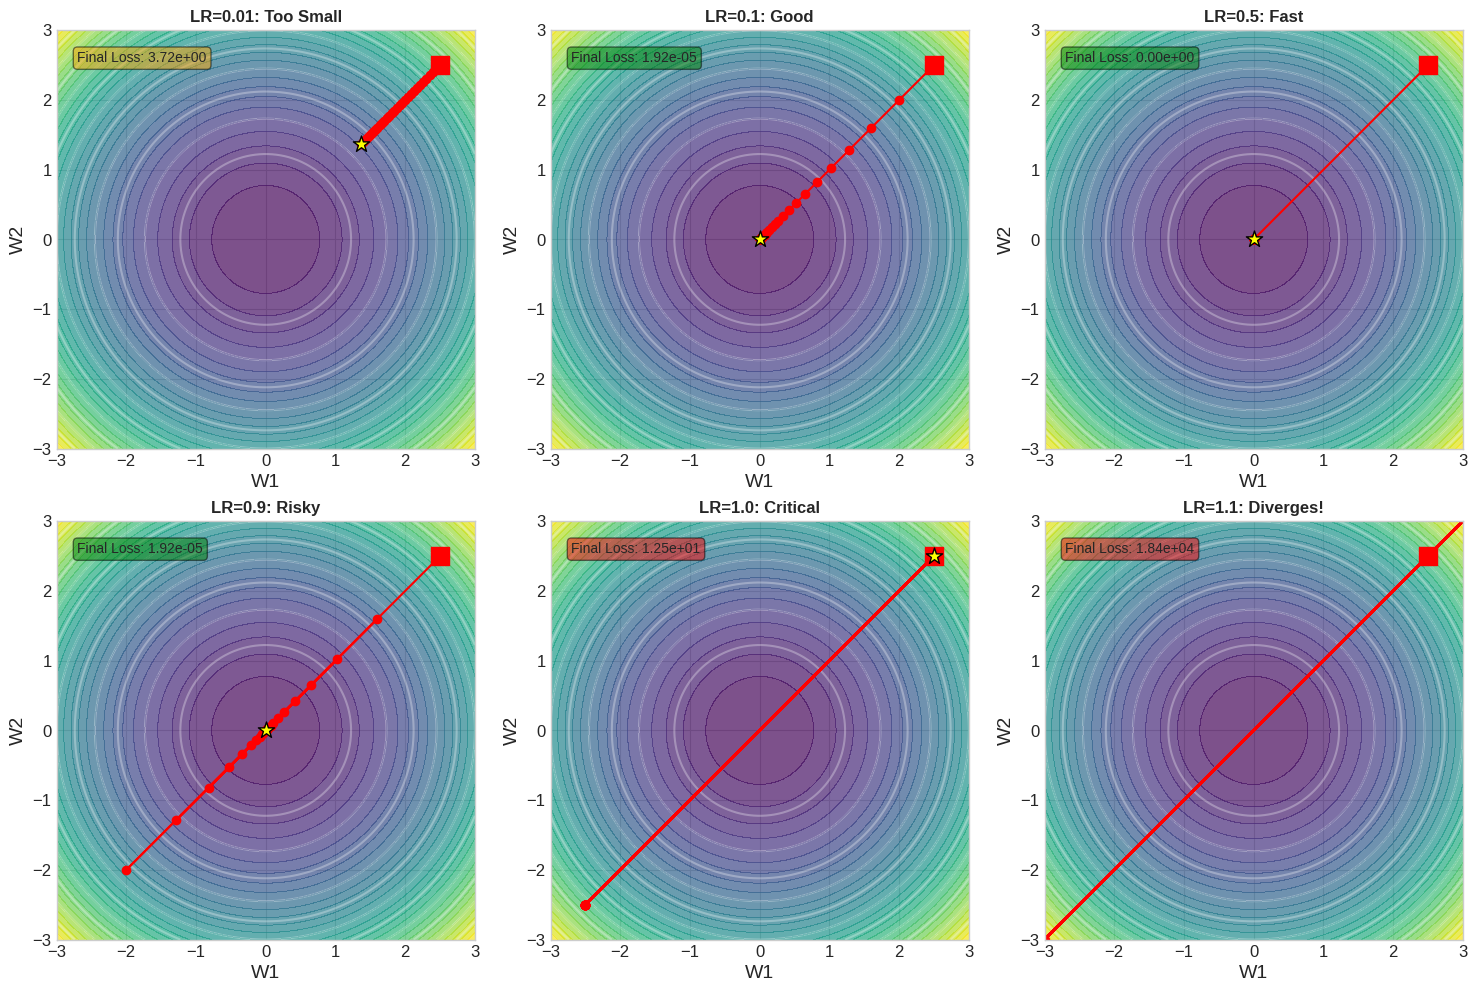


KEY INSIGHT: Learning rate is CRUCIAL for successful training!
Too small = slow, Too large = unstable/divergent
Typical starting values: 1e-3 to 1e-1 depending on optimizer


In [ ]:
# Demonstrate effect of different learning rates
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

learning_rates = [0.01, 0.1, 0.5, 0.9, 1.0, 1.1]
titles = ['LR=0.01: Too Small', 'LR=0.1: Good', 'LR=0.5: Fast',
          'LR=0.9: Risky', 'LR=1.0: Critical', 'LR=1.1: Diverges!']

x = np.linspace(-3, 3, 100)
y = np.linspace(-3, 3, 100)
X_lr, Y_lr = np.meshgrid(x, y)
Z_lr = X_lr**2 + Y_lr**2

for ax, lr, title in zip(axes.flat, learning_rates, titles):
    # Run GD with this learning rate
    opt = VanillaGradientDescent(learning_rate=lr)
    w_init = np.array([2.5, 2.5])

    try:
        w_final = opt.optimize(simple_loss, simple_grad, w_init, n_steps=30)
        history = np.array(opt.history)

        # Check for divergence
        if np.any(np.abs(history) > 100):
            history = history[np.all(np.abs(history) < 100, axis=1)]
    except:
        history = np.array([w_init])

    # Plot contour
    ax.contourf(X_lr, Y_lr, Z_lr, levels=30, cmap='viridis', alpha=0.7)
    ax.contour(X_lr, Y_lr, Z_lr, levels=15, colors='white', alpha=0.3)

    # Plot path
    if len(history) > 1:
        ax.plot(history[:, 0], history[:, 1], 'ro-', markersize=6, linewidth=1.5)
    ax.scatter([w_init[0]], [w_init[1]], color='red', s=150, marker='s', zorder=5)
    if len(history) > 1:
        ax.scatter([history[-1, 0]], [history[-1, 1]], color='yellow',
                   s=150, marker='*', zorder=5, edgecolor='black')

    ax.set_xlim(-3, 3)
    ax.set_ylim(-3, 3)
    ax.set_xlabel('W1')
    ax.set_ylabel('W2')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_aspect('equal')

    # Add loss info
    final_loss = simple_loss(history[-1]) if len(history) > 0 else float('inf')
    color = 'green' if final_loss < 0.1 else ('orange' if final_loss < 10 else 'red')
    ax.text(0.05, 0.95, f'Final Loss: {final_loss:.2e}',
            transform=ax.transAxes, fontsize=10,
            verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor=color, alpha=0.5))

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("KEY INSIGHT: Learning rate is CRUCIAL for successful training!")
print("Too small = slow, Too large = unstable/divergent")
print("Typical starting values: 1e-3 to 1e-1 depending on optimizer")
print("="*60)

---

# Part III: Problems with Vanilla Gradient Descent

---

## 3.1 The Ravine Problem (Ill-Conditioning)

In real neural networks, the loss landscape often has **ravines** - valleys that are steep in some directions but shallow in others.

### What Happens?

- Gradient descent oscillates in the steep direction
- Makes slow progress in the shallow direction
- Results in a "zig-zag" path that wastes computation

### Why Does This Happen in Deep Learning?

- Different layers have different scales
- Some features are more important than others
- Weight matrices often have different condition numbers

This is one of the most common problems in neural network training!

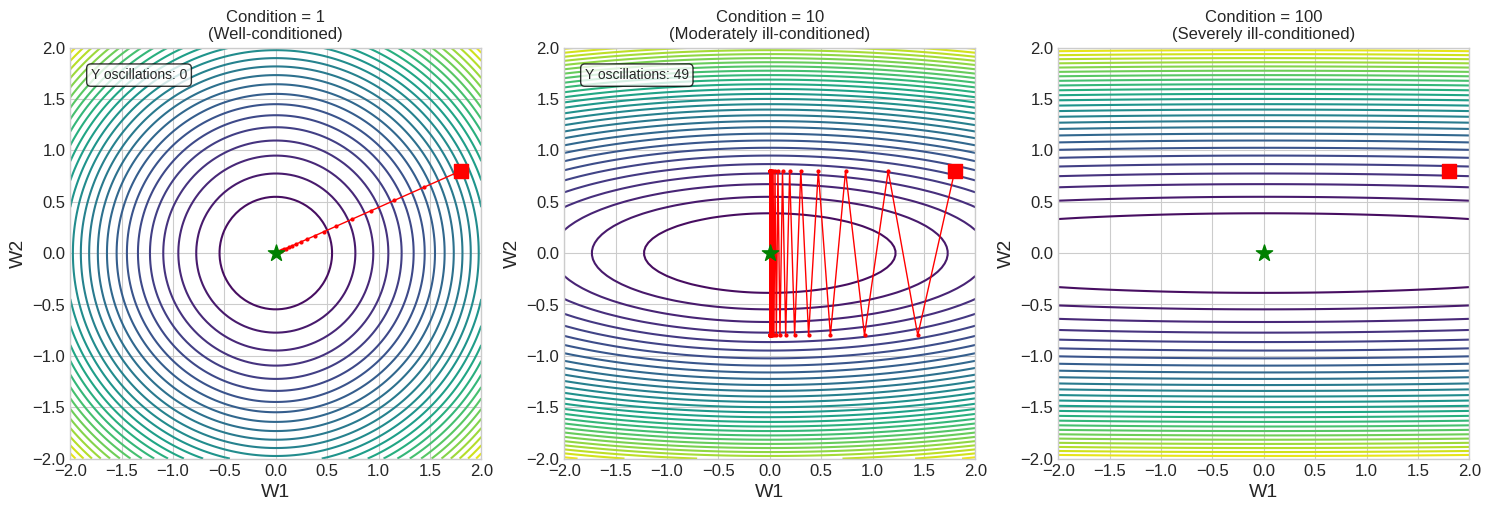


OBSERVATION: Higher condition numbers cause more oscillation!
The optimizer bounces back and forth in the steep Y direction
while making slow progress in the shallow X direction.


In [ ]:
# Demonstrate the ravine problem
def ravine_loss(w, condition=10):
    """Loss function with different curvatures: L = w1^2 + condition * w2^2"""
    return w[0]**2 + condition * w[1]**2

def ravine_grad(w, condition=10):
    """Gradient of ravine loss"""
    return np.array([2*w[0], 2*condition*w[1]])

# Visualize with different condition numbers
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

conditions = [1, 10, 100]
condition_titles = ['Condition = 1\n(Well-conditioned)',
                    'Condition = 10\n(Moderately ill-conditioned)',
                    'Condition = 100\n(Severely ill-conditioned)']

for ax, cond, title in zip(axes, conditions, condition_titles):
    # Create landscape
    x = np.linspace(-2, 2, 100)
    y = np.linspace(-2, 2, 100)
    X_r, Y_r = np.meshgrid(x, y)
    Z_r = X_r**2 + cond * Y_r**2

    ax.contour(X_r, Y_r, Z_r, levels=30, cmap='viridis')

    # Run gradient descent
    opt = VanillaGradientDescent(learning_rate=0.1)
    w_init = np.array([1.8, 0.8])

    loss_fn = lambda w: ravine_loss(w, cond)
    grad_fn = lambda w: ravine_grad(w, cond)

    try:
        w_final = opt.optimize(loss_fn, grad_fn, w_init, n_steps=50)
        history = np.array(opt.history)
        # Clip for visualization
        valid = np.all(np.abs(history) < 5, axis=1)
        history = history[valid]
    except:
        history = np.array([w_init])

    if len(history) > 1:
        ax.plot(history[:, 0], history[:, 1], 'r.-', markersize=4, linewidth=1)
    ax.scatter([w_init[0]], [w_init[1]], color='red', s=100, marker='s', zorder=5)
    ax.scatter([0], [0], color='green', s=150, marker='*', zorder=5)

    ax.set_xlabel('W1')
    ax.set_ylabel('W2')
    ax.set_title(title, fontsize=12)
    ax.set_xlim(-2, 2)
    ax.set_ylim(-2, 2)
    ax.set_aspect('equal')

    # Count oscillations in y direction
    if len(history) > 2:
        y_changes = np.diff(np.sign(history[1:, 1] - history[:-1, 1]))
        oscillations = np.sum(np.abs(y_changes) > 0)
        ax.text(0.05, 0.95, f'Y oscillations: {oscillations}',
                transform=ax.transAxes, fontsize=10,
                verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("OBSERVATION: Higher condition numbers cause more oscillation!")
print("The optimizer bounces back and forth in the steep Y direction")
print("while making slow progress in the shallow X direction.")
print("="*60)

## 3.2 Saddle Points: The Hidden Danger

In high-dimensional spaces (like neural networks with millions of parameters), **saddle points** are actually MORE common than local minima!

### What is a Saddle Point?

A point where:
- The gradient is zero (looks like a minimum)
- But it's a minimum in some directions and maximum in others
- Like the center of a horse saddle or a mountain pass

### Why Are They Problematic?

- Gradient is zero or near-zero → updates become tiny
- Optimizer can get "stuck" for many iterations
- Training progress appears to stall

### Research Insight
> "In high-dimensional optimization, the problem is not local minima but saddle points"
> - Dauphin et al., 2014

This is why we need smarter optimizers!

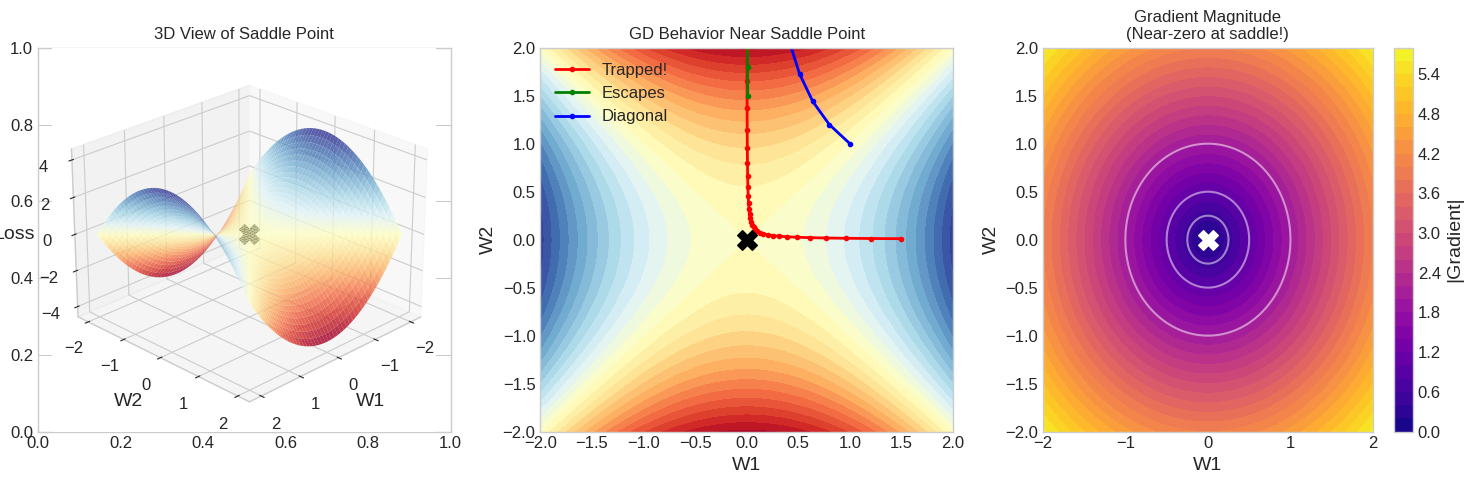


KEY INSIGHT: Near saddle points, gradients become tiny!
This causes optimization to slow down or get stuck.
Momentum and adaptive methods help escape saddle points.


In [ ]:
# Visualize saddle point behavior
def saddle_loss(w):
    """Saddle point loss: L = w1^2 - w2^2"""
    return w[0]**2 - w[1]**2

def saddle_grad(w):
    """Gradient of saddle loss"""
    return np.array([2*w[0], -2*w[1]])

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# 3D visualization of saddle point
ax = fig.add_subplot(131, projection='3d')
x = np.linspace(-2, 2, 50)
y = np.linspace(-2, 2, 50)
X_s, Y_s = np.meshgrid(x, y)
Z_s = X_s**2 - Y_s**2

ax.plot_surface(X_s, Y_s, Z_s, cmap='RdYlBu', alpha=0.8)
ax.scatter([0], [0], [0], color='black', s=200, marker='X', zorder=5)
ax.set_xlabel('W1')
ax.set_ylabel('W2')
ax.set_zlabel('Loss')
ax.set_title('3D View of Saddle Point', fontsize=12)
ax.view_init(elev=25, azim=45)

# Contour with gradient descent paths
ax = axes[1]
x = np.linspace(-2, 2, 100)
y = np.linspace(-2, 2, 100)
X_s2, Y_s2 = np.meshgrid(x, y)
Z_s2 = X_s2**2 - Y_s2**2

ax.contourf(X_s2, Y_s2, Z_s2, levels=30, cmap='RdYlBu')
ax.scatter([0], [0], color='black', s=200, marker='X', zorder=5)

# Run GD from different starting points
starting_points = [
    np.array([1.5, 0.01]),   # Almost on x-axis - should converge to saddle
    np.array([0.01, 1.5]),   # Almost on y-axis - should escape
    np.array([1.0, 1.0]),    # Diagonal - behavior depends on initialization
]
colors = ['red', 'green', 'blue']
labels = ['Trapped!', 'Escapes', 'Diagonal']

for w_init, color, label in zip(starting_points, colors, labels):
    opt = VanillaGradientDescent(learning_rate=0.1)
    try:
        w_final = opt.optimize(saddle_loss, saddle_grad, w_init, n_steps=30)
        history = np.array(opt.history)
        valid = np.all(np.abs(history) < 5, axis=1)
        history = history[valid]
    except:
        history = np.array([w_init])

    if len(history) > 1:
        ax.plot(history[:, 0], history[:, 1], '.-', color=color,
                markersize=6, linewidth=2, label=label)

ax.set_xlabel('W1')
ax.set_ylabel('W2')
ax.set_title('GD Behavior Near Saddle Point', fontsize=12)
ax.legend()
ax.set_xlim(-2, 2)
ax.set_ylim(-2, 2)

# Show gradient magnitude near saddle point
ax = axes[2]
grad_magnitude = np.sqrt((2*X_s2)**2 + (2*Y_s2)**2)
im = ax.contourf(X_s2, Y_s2, grad_magnitude, levels=30, cmap='plasma')
ax.scatter([0], [0], color='white', s=200, marker='X', zorder=5)
ax.contour(X_s2, Y_s2, grad_magnitude, levels=[0.5, 1, 2], colors='white', alpha=0.5)
plt.colorbar(im, ax=ax, label='|Gradient|')
ax.set_xlabel('W1')
ax.set_ylabel('W2')
ax.set_title('Gradient Magnitude\n(Near-zero at saddle!)', fontsize=12)
ax.set_xlim(-2, 2)
ax.set_ylim(-2, 2)

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("KEY INSIGHT: Near saddle points, gradients become tiny!")
print("This causes optimization to slow down or get stuck.")
print("Momentum and adaptive methods help escape saddle points.")
print("="*60)

---

# Part IV: Stochastic Gradient Descent (SGD)

---

## 4.1 From Batch to Stochastic

So far, we've been using **Batch Gradient Descent** - computing gradients using ALL training data. But this has problems:

| Aspect | Batch GD | Stochastic GD |
|--------|----------|---------------|
| **Gradient computed on** | Entire dataset | Single sample or mini-batch |
| **Memory usage** | Very high | Low |
| **Update frequency** | Once per epoch | Many times per epoch |
| **Gradient quality** | Exact | Noisy (but unbiased) |
| **Can escape local minima?** | No | Yes (noise helps!) |

### The Key Insight

**Noise is a feature, not a bug!**

The noise in SGD:
- Helps escape shallow local minima
- Provides implicit regularization
- Enables training on huge datasets

### Mini-batch Gradient Descent

In practice, we use **mini-batches** (typically 32-256 samples):
- Balance between noise and stability
- Efficient use of GPU parallelism
- Standard in modern deep learning

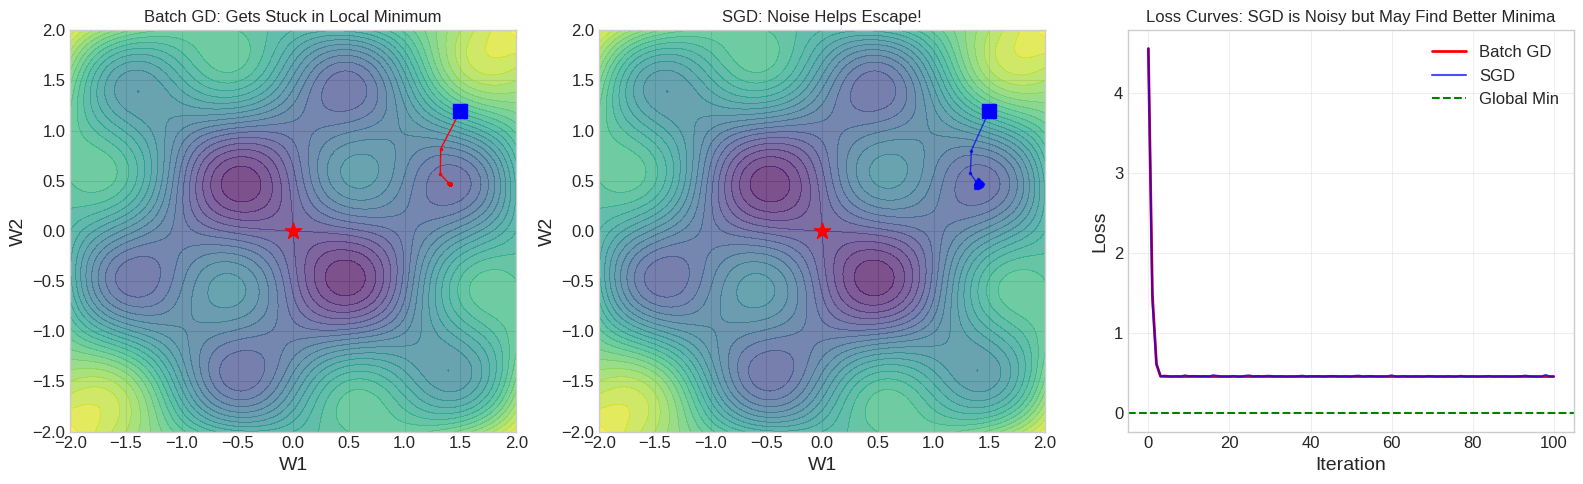


KEY INSIGHT: SGD's noise can help escape local minima!
This is why SGD often finds better solutions than exact methods.


In [ ]:
# Visualize the difference between Batch GD and SGD
np.random.seed(42)

# Create a simple multimodal loss function
def multimodal_loss(w):
    """Loss with multiple minima"""
    return (w[0]**2 + w[1]**2) + 2*np.sin(3*w[0])*np.sin(3*w[1])

def multimodal_grad(w):
    """Gradient of multimodal loss"""
    dw1 = 2*w[0] + 6*np.cos(3*w[0])*np.sin(3*w[1])
    dw2 = 2*w[1] + 6*np.sin(3*w[0])*np.cos(3*w[1])
    return np.array([dw1, dw2])

class SGD:
    """Stochastic Gradient Descent with noise simulation."""

    def __init__(self, learning_rate=0.1, noise_scale=0.5):
        self.lr = learning_rate
        self.noise_scale = noise_scale
        self.history = []

    def optimize(self, loss_fn, grad_fn, w_init, n_steps=100):
        w = w_init.copy()
        self.history = [w.copy()]

        for _ in range(n_steps):
            grad = grad_fn(w)
            # Add noise to simulate stochastic gradient
            noise = np.random.randn(len(w)) * self.noise_scale
            noisy_grad = grad + noise
            w = w - self.lr * noisy_grad
            self.history.append(w.copy())

        return w

# Compare Batch GD vs SGD
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Create landscape
x = np.linspace(-2, 2, 100)
y = np.linspace(-2, 2, 100)
X_m, Y_m = np.meshgrid(x, y)
Z_m = (X_m**2 + Y_m**2) + 2*np.sin(3*X_m)*np.sin(3*Y_m)

# Plot 1: Batch GD (gets stuck in local minimum)
ax = axes[0]
ax.contourf(X_m, Y_m, Z_m, levels=30, cmap='viridis', alpha=0.7)
ax.scatter([0], [0], color='red', s=150, marker='*', zorder=5, label='Global Min')

w_init = np.array([1.5, 1.2])
opt_batch = VanillaGradientDescent(learning_rate=0.05)
opt_batch.optimize(multimodal_loss, multimodal_grad, w_init, n_steps=100)
history_batch = np.array(opt_batch.history)
ax.plot(history_batch[:, 0], history_batch[:, 1], 'r.-', markersize=3, linewidth=1)
ax.scatter([w_init[0]], [w_init[1]], color='blue', s=100, marker='s', zorder=5)

ax.set_xlabel('W1')
ax.set_ylabel('W2')
ax.set_title('Batch GD: Gets Stuck in Local Minimum', fontsize=12)
ax.set_xlim(-2, 2)
ax.set_ylim(-2, 2)

# Plot 2: SGD (may escape due to noise)
ax = axes[1]
ax.contourf(X_m, Y_m, Z_m, levels=30, cmap='viridis', alpha=0.7)
ax.scatter([0], [0], color='red', s=150, marker='*', zorder=5, label='Global Min')

np.random.seed(123)  # Different seed for different trajectory
opt_sgd = SGD(learning_rate=0.05, noise_scale=0.3)
opt_sgd.optimize(multimodal_loss, multimodal_grad, w_init, n_steps=100)
history_sgd = np.array(opt_sgd.history)
ax.plot(history_sgd[:, 0], history_sgd[:, 1], 'b.-', markersize=3, linewidth=1, alpha=0.7)
ax.scatter([w_init[0]], [w_init[1]], color='blue', s=100, marker='s', zorder=5)

ax.set_xlabel('W1')
ax.set_ylabel('W2')
ax.set_title('SGD: Noise Helps Escape!', fontsize=12)
ax.set_xlim(-2, 2)
ax.set_ylim(-2, 2)

# Plot 3: Loss comparison
ax = axes[2]
losses_batch = [multimodal_loss(w) for w in history_batch]
losses_sgd = [multimodal_loss(w) for w in history_sgd]

ax.plot(losses_batch, 'r-', linewidth=2, label='Batch GD')
ax.plot(losses_sgd, 'b-', linewidth=1.5, alpha=0.7, label='SGD')
ax.axhline(y=multimodal_loss(np.array([0, 0])), color='green',
           linestyle='--', label='Global Min')
ax.set_xlabel('Iteration')
ax.set_ylabel('Loss')
ax.set_title('Loss Curves: SGD is Noisy but May Find Better Minima', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("KEY INSIGHT: SGD's noise can help escape local minima!")
print("This is why SGD often finds better solutions than exact methods.")
print("="*60)

## 4.2 Batch Size Effects

The **batch size** controls the trade-off between:
- **Small batches**: More noise, more frequent updates, less memory
- **Large batches**: Less noise, more stable, more memory, can use GPU better

### Typical Batch Sizes in Practice

| Domain | Typical Batch Size | Reason |
|--------|-------------------|--------|
| Image Classification | 32-256 | GPU memory limits |
| NLP/Transformers | 8-64 | Large models |
| Large-scale Training | 1024-32768 | Distributed training |

### The Learning Rate - Batch Size Relationship

**Important Rule**: When you increase batch size, increase learning rate!
- Linear scaling: `LR_new = LR_old * (batch_new / batch_old)`
- This keeps the expected weight update magnitude similar

---

# Part V: Momentum Methods

---

## 5.1 The Physics Intuition

Imagine a ball rolling down a hill:
- It **accelerates** as it rolls downhill
- It has **momentum** that carries it through small bumps
- It can **roll over** small hills if going fast enough

This is exactly what **momentum** does for optimization!

### SGD with Momentum

Instead of just using the current gradient, we accumulate a "velocity":

$$v_t = \beta v_{t-1} + \nabla L(W_t)$$
$$W_{t+1} = W_t - \eta \cdot v_t$$

Where:
- $v$ = velocity (accumulated gradient)
- $\beta$ = momentum coefficient (typically 0.9)
- $\eta$ = learning rate

### Why Momentum Helps

1. **Dampens oscillations**: In ravines, oscillations in steep directions get cancelled
2. **Accelerates convergence**: In consistent directions, momentum builds up
3. **Helps escape saddle points**: Accumulated velocity carries past flat regions

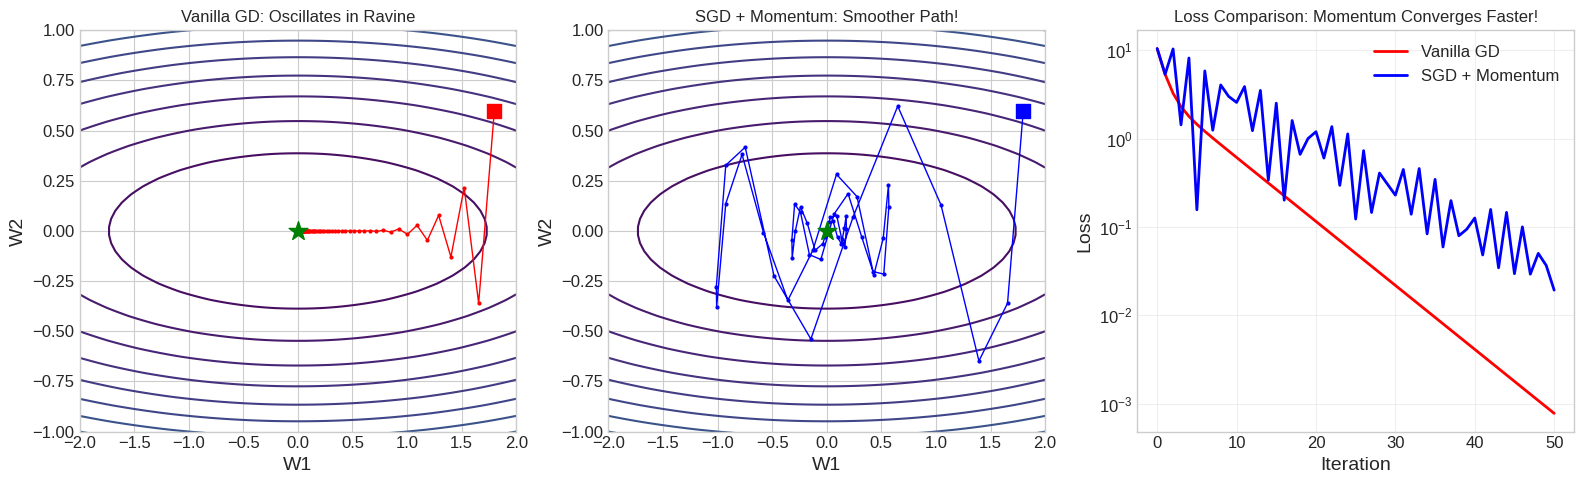


KEY INSIGHT: Momentum dampens oscillations and accelerates convergence!
The momentum term 'remembers' previous gradients, smoothing the path.


In [ ]:
# Implement SGD with Momentum
class SGDMomentum:
    """SGD with Momentum optimizer."""

    def __init__(self, learning_rate=0.1, momentum=0.9):
        self.lr = learning_rate
        self.momentum = momentum
        self.history = []

    def optimize(self, loss_fn, grad_fn, w_init, n_steps=50):
        w = w_init.copy()
        v = np.zeros_like(w)  # Initialize velocity
        self.history = [w.copy()]

        for _ in range(n_steps):
            grad = grad_fn(w)
            v = self.momentum * v + grad  # Update velocity
            w = w - self.lr * v  # Update parameters
            self.history.append(w.copy())

        return w

# Compare GD vs Momentum on a ravine
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Create ravine landscape (ill-conditioned)
x = np.linspace(-2, 2, 100)
y = np.linspace(-2, 2, 100)
X_r, Y_r = np.meshgrid(x, y)
Z_r = X_r**2 + 20*Y_r**2  # Ravine

w_init = np.array([1.8, 0.6])

# Plot 1: Vanilla GD (oscillates)
ax = axes[0]
ax.contour(X_r, Y_r, Z_r, levels=30, cmap='viridis')
ax.scatter([0], [0], color='green', s=200, marker='*', zorder=5)

opt_gd = VanillaGradientDescent(learning_rate=0.04)
opt_gd.optimize(lambda w: w[0]**2 + 20*w[1]**2,
                lambda w: np.array([2*w[0], 40*w[1]]), w_init, n_steps=50)
history_gd = np.array(opt_gd.history)
ax.plot(history_gd[:, 0], history_gd[:, 1], 'r.-', markersize=4, linewidth=1, label='Path')
ax.scatter([w_init[0]], [w_init[1]], color='red', s=100, marker='s', zorder=5)

ax.set_xlabel('W1')
ax.set_ylabel('W2')
ax.set_title('Vanilla GD: Oscillates in Ravine', fontsize=12)
ax.set_xlim(-2, 2)
ax.set_ylim(-1, 1)

# Plot 2: SGD with Momentum (smoother)
ax = axes[1]
ax.contour(X_r, Y_r, Z_r, levels=30, cmap='viridis')
ax.scatter([0], [0], color='green', s=200, marker='*', zorder=5)

opt_mom = SGDMomentum(learning_rate=0.04, momentum=0.9)
opt_mom.optimize(lambda w: w[0]**2 + 20*w[1]**2,
                 lambda w: np.array([2*w[0], 40*w[1]]), w_init, n_steps=50)
history_mom = np.array(opt_mom.history)
ax.plot(history_mom[:, 0], history_mom[:, 1], 'b.-', markersize=4, linewidth=1, label='Path')
ax.scatter([w_init[0]], [w_init[1]], color='blue', s=100, marker='s', zorder=5)

ax.set_xlabel('W1')
ax.set_ylabel('W2')
ax.set_title('SGD + Momentum: Smoother Path!', fontsize=12)
ax.set_xlim(-2, 2)
ax.set_ylim(-1, 1)

# Plot 3: Loss comparison
ax = axes[2]
losses_gd = [w[0]**2 + 20*w[1]**2 for w in history_gd]
losses_mom = [w[0]**2 + 20*w[1]**2 for w in history_mom]

ax.plot(losses_gd, 'r-', linewidth=2, label='Vanilla GD')
ax.plot(losses_mom, 'b-', linewidth=2, label='SGD + Momentum')
ax.set_xlabel('Iteration')
ax.set_ylabel('Loss')
ax.set_title('Loss Comparison: Momentum Converges Faster!', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_yscale('log')

plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("KEY INSIGHT: Momentum dampens oscillations and accelerates convergence!")
print("The momentum term 'remembers' previous gradients, smoothing the path.")
print("="*70)

## 5.2 Nesterov Accelerated Gradient (NAG)

NAG is a clever improvement over standard momentum:

**Standard Momentum**: Look at gradient at current position, then move
**Nesterov**: Look ahead to where momentum would take us, compute gradient there

$$v_t = \beta v_{t-1} + \nabla L(W_t - \beta v_{t-1})$$
$$W_{t+1} = W_t - \eta \cdot v_t$$

### Why is NAG Better?

- **Anticipatory**: It "looks ahead" before making the update
- **Better corrections**: Can correct overshooting faster
- **Proven faster convergence**: Theoretically optimal for convex functions

---

# Part VI: Adaptive Learning Rate Methods

---

## 6.1 The Problem with Fixed Learning Rates

Different parameters may need different learning rates:
- **Sparse features** (rarely updated) → need larger learning rates
- **Frequent features** (often updated) → need smaller learning rates
- **Different layers** have different gradient scales

### The Solution: Adapt Learning Rates Per-Parameter!

Adaptive methods automatically adjust the learning rate for each parameter based on its history of gradients.

## 6.2 AdaGrad (Adaptive Gradient)

**Key Idea**: Accumulate squared gradients, use to scale learning rate

$$g_t = g_{t-1} + (\nabla L)^2$$
$$W_{t+1} = W_t - \frac{\eta}{\sqrt{g_t + \epsilon}} \cdot \nabla L$$

Where:
- $g$ = accumulated squared gradients
- $\epsilon$ = small constant for numerical stability (typically 1e-8)

### Properties
- Parameters with large gradients → smaller effective LR
- Parameters with small gradients → larger effective LR
- **Problem**: Learning rate monotonically decreases → can stop learning!

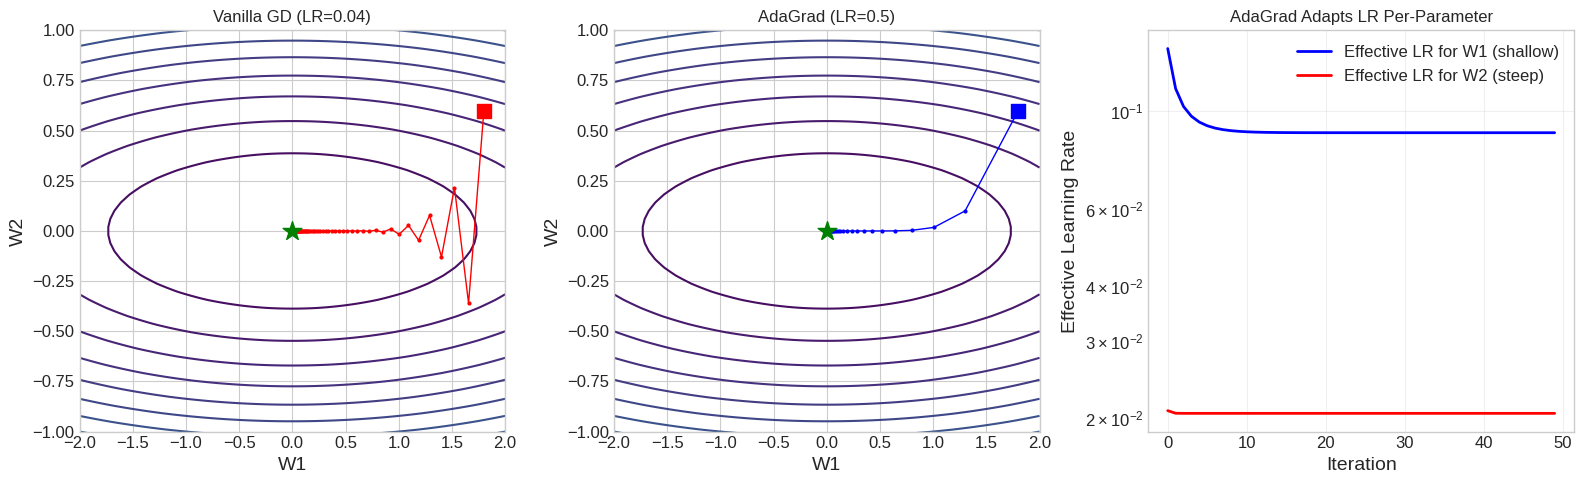


KEY INSIGHT: AdaGrad automatically reduces LR for steep directions!
But it accumulates forever, so LR can become too small over time.


In [ ]:
# Implement AdaGrad
class AdaGrad:
    """AdaGrad optimizer."""

    def __init__(self, learning_rate=0.5, epsilon=1e-8):
        self.lr = learning_rate
        self.epsilon = epsilon
        self.history = []

    def optimize(self, loss_fn, grad_fn, w_init, n_steps=50):
        w = w_init.copy()
        g = np.zeros_like(w)  # Accumulated squared gradients
        self.history = [w.copy()]

        for _ in range(n_steps):
            grad = grad_fn(w)
            g = g + grad**2  # Accumulate squared gradients
            w = w - (self.lr / (np.sqrt(g) + self.epsilon)) * grad
            self.history.append(w.copy())

        return w

# Visualize AdaGrad behavior
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Ravine landscape
x = np.linspace(-2, 2, 100)
y = np.linspace(-2, 2, 100)
X_r, Y_r = np.meshgrid(x, y)
Z_r = X_r**2 + 20*Y_r**2

w_init = np.array([1.8, 0.6])
ravine_loss = lambda w: w[0]**2 + 20*w[1]**2
ravine_grad = lambda w: np.array([2*w[0], 40*w[1]])

# Plot 1: Vanilla GD
ax = axes[0]
ax.contour(X_r, Y_r, Z_r, levels=30, cmap='viridis')
ax.scatter([0], [0], color='green', s=200, marker='*', zorder=5)

opt_gd = VanillaGradientDescent(learning_rate=0.04)
opt_gd.optimize(ravine_loss, ravine_grad, w_init, n_steps=50)
history_gd = np.array(opt_gd.history)
ax.plot(history_gd[:, 0], history_gd[:, 1], 'r.-', markersize=4, linewidth=1)
ax.scatter([w_init[0]], [w_init[1]], color='red', s=100, marker='s', zorder=5)
ax.set_title('Vanilla GD (LR=0.04)', fontsize=12)
ax.set_xlabel('W1')
ax.set_ylabel('W2')
ax.set_xlim(-2, 2)
ax.set_ylim(-1, 1)

# Plot 2: AdaGrad
ax = axes[1]
ax.contour(X_r, Y_r, Z_r, levels=30, cmap='viridis')
ax.scatter([0], [0], color='green', s=200, marker='*', zorder=5)

opt_ada = AdaGrad(learning_rate=0.5)
opt_ada.optimize(ravine_loss, ravine_grad, w_init, n_steps=50)
history_ada = np.array(opt_ada.history)
ax.plot(history_ada[:, 0], history_ada[:, 1], 'b.-', markersize=4, linewidth=1)
ax.scatter([w_init[0]], [w_init[1]], color='blue', s=100, marker='s', zorder=5)
ax.set_title('AdaGrad (LR=0.5)', fontsize=12)
ax.set_xlabel('W1')
ax.set_ylabel('W2')
ax.set_xlim(-2, 2)
ax.set_ylim(-1, 1)

# Plot 3: Effective learning rates over time
ax = axes[2]
# Track effective learning rate in each direction
g1, g2 = 0.0, 0.0
eff_lr1, eff_lr2 = [], []
w_track = w_init.copy()
for _ in range(50):
    grad = ravine_grad(w_track)
    g1 += grad[0]**2
    g2 += grad[1]**2
    eff_lr1.append(0.5 / (np.sqrt(g1) + 1e-8))
    eff_lr2.append(0.5 / (np.sqrt(g2) + 1e-8))
    w_track = w_track - np.array([eff_lr1[-1] * grad[0], eff_lr2[-1] * grad[1]])

ax.plot(eff_lr1, 'b-', linewidth=2, label='Effective LR for W1 (shallow)')
ax.plot(eff_lr2, 'r-', linewidth=2, label='Effective LR for W2 (steep)')
ax.set_xlabel('Iteration')
ax.set_ylabel('Effective Learning Rate')
ax.set_title('AdaGrad Adapts LR Per-Parameter', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_yscale('log')

plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("KEY INSIGHT: AdaGrad automatically reduces LR for steep directions!")
print("But it accumulates forever, so LR can become too small over time.")
print("="*70)

## 6.3 RMSprop (Root Mean Square Propagation)

**Key Idea**: Use exponential moving average instead of accumulation

$$v_t = \beta v_{t-1} + (1-\beta)(\nabla L)^2$$
$$W_{t+1} = W_t - \frac{\eta}{\sqrt{v_t + \epsilon}} \cdot \nabla L$$

Where:
- $v$ = exponential moving average of squared gradients
- $\beta$ = decay rate (typically 0.9 or 0.99)

### Why RMSprop is Better than AdaGrad

- **Doesn't accumulate forever**: Uses moving average
- **Forgets old gradients**: Adapts to recent gradient magnitudes
- **Works for non-stationary problems**: Deep learning landscapes change during training

### RMSprop vs AdaGrad

| Aspect | AdaGrad | RMSprop |
|--------|---------|---------|
| Memory | Accumulates forever | Exponential decay |
| LR over time | Monotonically decreases | Can increase/decrease |
| Best for | Sparse gradients, convex | Deep learning |

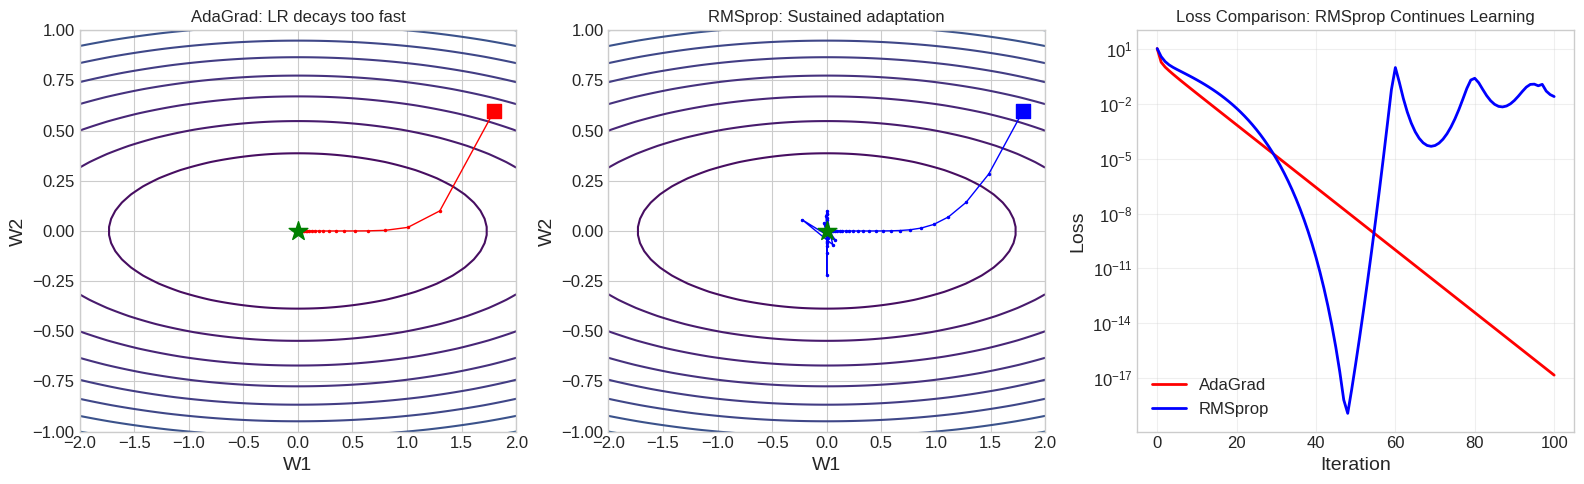


KEY INSIGHT: RMSprop uses exponential moving average to avoid
the vanishing learning rate problem of AdaGrad!


In [ ]:
# Implement RMSprop
class RMSprop:
    """RMSprop optimizer."""

    def __init__(self, learning_rate=0.1, beta=0.9, epsilon=1e-8):
        self.lr = learning_rate
        self.beta = beta
        self.epsilon = epsilon
        self.history = []

    def optimize(self, loss_fn, grad_fn, w_init, n_steps=50):
        w = w_init.copy()
        v = np.zeros_like(w)  # Moving average of squared gradients
        self.history = [w.copy()]

        for _ in range(n_steps):
            grad = grad_fn(w)
            v = self.beta * v + (1 - self.beta) * grad**2  # EMA of squared gradients
            w = w - (self.lr / (np.sqrt(v) + self.epsilon)) * grad
            self.history.append(w.copy())

        return w

# Compare AdaGrad vs RMSprop
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

w_init = np.array([1.8, 0.6])

# Plot 1: AdaGrad
ax = axes[0]
ax.contour(X_r, Y_r, Z_r, levels=30, cmap='viridis')
ax.scatter([0], [0], color='green', s=200, marker='*', zorder=5)
opt_ada = AdaGrad(learning_rate=0.5)
opt_ada.optimize(ravine_loss, ravine_grad, w_init, n_steps=100)
history_ada = np.array(opt_ada.history)
ax.plot(history_ada[:, 0], history_ada[:, 1], 'r.-', markersize=3, linewidth=1)
ax.scatter([w_init[0]], [w_init[1]], color='red', s=100, marker='s', zorder=5)
ax.set_title('AdaGrad: LR decays too fast', fontsize=12)
ax.set_xlabel('W1')
ax.set_ylabel('W2')
ax.set_xlim(-2, 2)
ax.set_ylim(-1, 1)

# Plot 2: RMSprop
ax = axes[1]
ax.contour(X_r, Y_r, Z_r, levels=30, cmap='viridis')
ax.scatter([0], [0], color='green', s=200, marker='*', zorder=5)
opt_rms = RMSprop(learning_rate=0.1, beta=0.9)
opt_rms.optimize(ravine_loss, ravine_grad, w_init, n_steps=100)
history_rms = np.array(opt_rms.history)
ax.plot(history_rms[:, 0], history_rms[:, 1], 'b.-', markersize=3, linewidth=1)
ax.scatter([w_init[0]], [w_init[1]], color='blue', s=100, marker='s', zorder=5)
ax.set_title('RMSprop: Sustained adaptation', fontsize=12)
ax.set_xlabel('W1')
ax.set_ylabel('W2')
ax.set_xlim(-2, 2)
ax.set_ylim(-1, 1)

# Plot 3: Loss comparison
ax = axes[2]
losses_ada = [ravine_loss(w) for w in history_ada]
losses_rms = [ravine_loss(w) for w in history_rms]
ax.plot(losses_ada, 'r-', linewidth=2, label='AdaGrad')
ax.plot(losses_rms, 'b-', linewidth=2, label='RMSprop')
ax.set_xlabel('Iteration')
ax.set_ylabel('Loss')
ax.set_title('Loss Comparison: RMSprop Continues Learning', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_yscale('log')

plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("KEY INSIGHT: RMSprop uses exponential moving average to avoid")
print("the vanishing learning rate problem of AdaGrad!")
print("="*70)

---

# Part VII: Adam and the Adam Family

---

## 7.1 Adam: Adaptive Moment Estimation

Adam combines the best of **Momentum** and **RMSprop**:

**Momentum**: Remembers direction (first moment - mean of gradients)
**RMSprop**: Remembers magnitude (second moment - variance of gradients)
**Adam**: Uses both!

### The Algorithm

$$m_t = \beta_1 m_{t-1} + (1-\beta_1) \nabla L \quad \text{(momentum)}$$
$$v_t = \beta_2 v_{t-1} + (1-\beta_2) (\nabla L)^2 \quad \text{(RMSprop)}$$
$$\hat{m}_t = \frac{m_t}{1-\beta_1^t} \quad \text{(bias correction)}$$
$$\hat{v}_t = \frac{v_t}{1-\beta_2^t} \quad \text{(bias correction)}$$
$$W_{t+1} = W_t - \frac{\eta}{\sqrt{\hat{v}_t} + \epsilon} \hat{m}_t$$

### Default Hyperparameters (work well for most cases!)
- $\eta = 0.001$ (learning rate)
- $\beta_1 = 0.9$ (momentum decay)
- $\beta_2 = 0.999$ (RMSprop decay)
- $\epsilon = 10^{-8}$ (numerical stability)

### Why Bias Correction?

At the start of training, $m$ and $v$ are initialized to zero. Without correction, they'd be biased toward zero in early steps. The bias correction compensates for this.

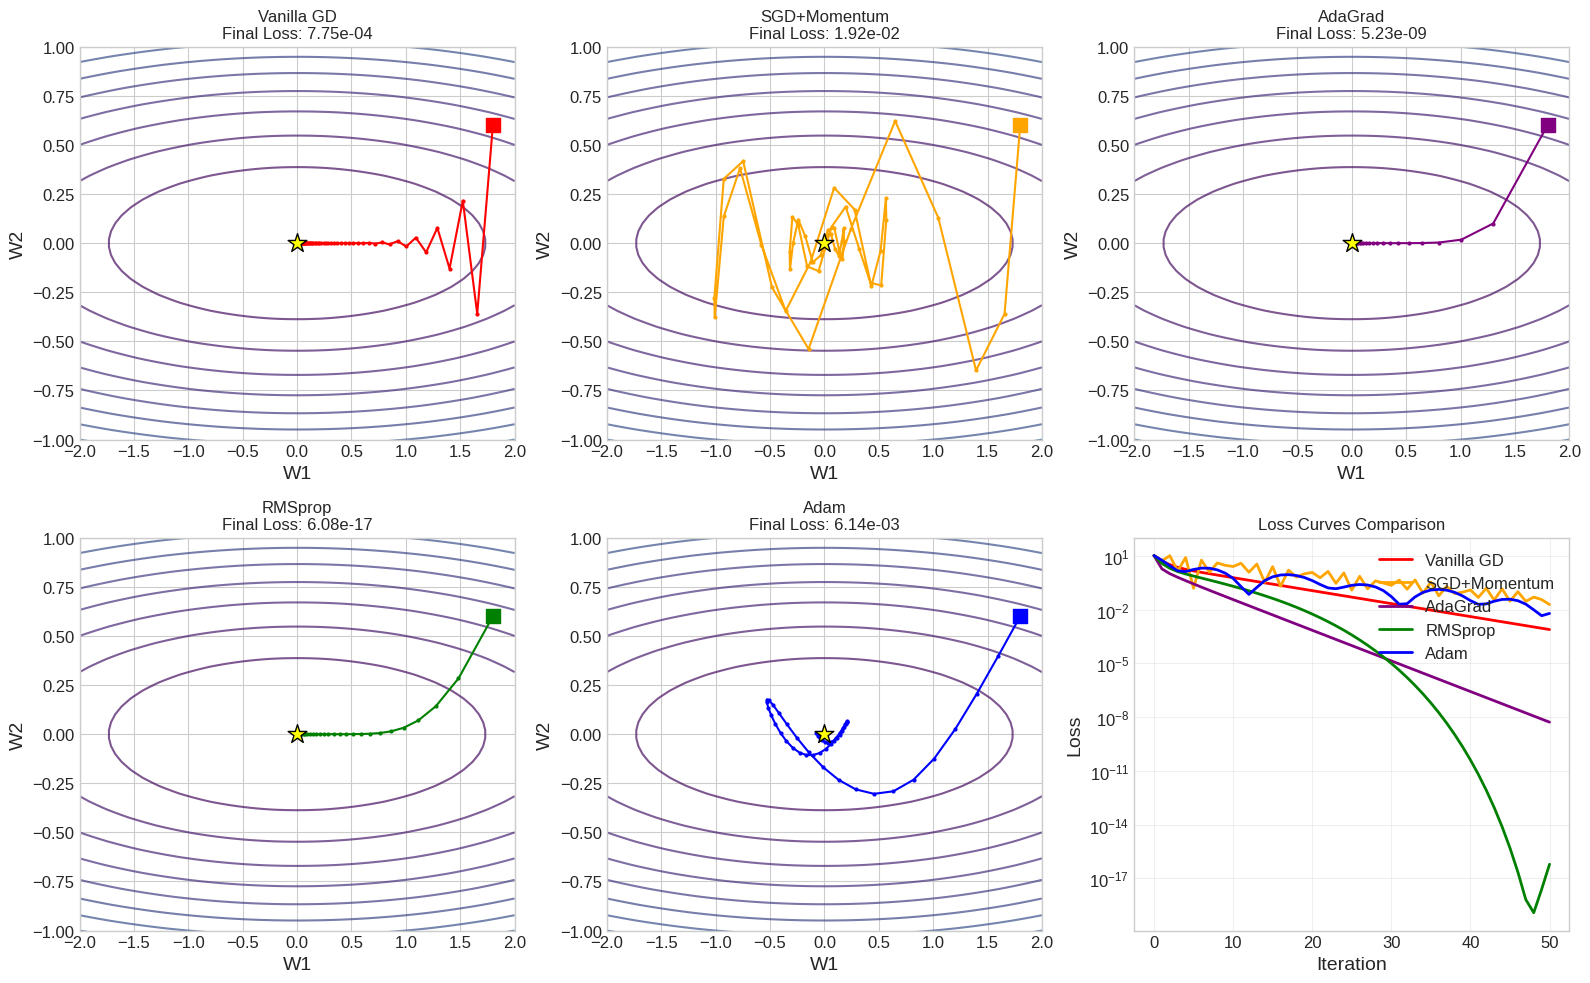


KEY INSIGHT: Adam combines momentum + adaptive LR for robust optimization!
It's the default choice for most deep learning tasks.


In [ ]:
# Implement Adam
class Adam:
    """Adam optimizer with bias correction."""

    def __init__(self, learning_rate=0.001, beta1=0.9, beta2=0.999, epsilon=1e-8):
        self.lr = learning_rate
        self.beta1 = beta1
        self.beta2 = beta2
        self.epsilon = epsilon
        self.history = []

    def optimize(self, loss_fn, grad_fn, w_init, n_steps=50):
        w = w_init.copy()
        m = np.zeros_like(w)  # First moment (momentum)
        v = np.zeros_like(w)  # Second moment (RMSprop)
        self.history = [w.copy()]

        for t in range(1, n_steps + 1):
            grad = grad_fn(w)

            # Update moments
            m = self.beta1 * m + (1 - self.beta1) * grad
            v = self.beta2 * v + (1 - self.beta2) * grad**2

            # Bias correction
            m_hat = m / (1 - self.beta1**t)
            v_hat = v / (1 - self.beta2**t)

            # Update parameters
            w = w - self.lr * m_hat / (np.sqrt(v_hat) + self.epsilon)
            self.history.append(w.copy())

        return w

# Grand comparison of all optimizers
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

w_init = np.array([1.8, 0.6])

optimizers = [
    ('Vanilla GD', VanillaGradientDescent(learning_rate=0.04), 'red'),
    ('SGD+Momentum', SGDMomentum(learning_rate=0.04, momentum=0.9), 'orange'),
    ('AdaGrad', AdaGrad(learning_rate=0.5), 'purple'),
    ('RMSprop', RMSprop(learning_rate=0.1, beta=0.9), 'green'),
    ('Adam', Adam(learning_rate=0.2, beta1=0.9, beta2=0.999), 'blue'),
]

# Plot each optimizer's path
for ax, (name, opt, color) in zip(axes.flat[:5], optimizers):
    ax.contour(X_r, Y_r, Z_r, levels=30, cmap='viridis', alpha=0.7)
    ax.scatter([0], [0], color='yellow', s=200, marker='*', zorder=5, edgecolor='black')

    opt.optimize(ravine_loss, ravine_grad, w_init, n_steps=50)
    history = np.array(opt.history)
    ax.plot(history[:, 0], history[:, 1], '.-', color=color, markersize=4, linewidth=1.5)
    ax.scatter([w_init[0]], [w_init[1]], color=color, s=100, marker='s', zorder=5)

    final_loss = ravine_loss(history[-1])
    ax.set_title(f'{name}\nFinal Loss: {final_loss:.2e}', fontsize=12)
    ax.set_xlabel('W1')
    ax.set_ylabel('W2')
    ax.set_xlim(-2, 2)
    ax.set_ylim(-1, 1)

# Plot 6: Loss curves comparison
ax = axes.flat[5]
for name, opt, color in optimizers:
    opt.optimize(ravine_loss, ravine_grad, w_init, n_steps=50)
    losses = [ravine_loss(w) for w in opt.history]
    ax.plot(losses, color=color, linewidth=2, label=name)

ax.set_xlabel('Iteration')
ax.set_ylabel('Loss')
ax.set_title('Loss Curves Comparison', fontsize=12)
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)
ax.set_yscale('log')

plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("KEY INSIGHT: Adam combines momentum + adaptive LR for robust optimization!")
print("It's the default choice for most deep learning tasks.")
print("="*70)

## 7.2 AdamW: Weight Decay Done Right

**Problem with L2 regularization in Adam**: When you add L2 regularization to the loss:
$$L_{regularized} = L + \frac{\lambda}{2}||W||^2$$

The gradient becomes $\nabla L + \lambda W$. But Adam scales ALL gradients by the adaptive learning rate, so regularization strength becomes inconsistent!

**AdamW Solution**: Apply weight decay AFTER the Adam update, not before:

$$W_{t+1} = W_t - \eta \cdot \left( \frac{\hat{m}_t}{\sqrt{\hat{v}_t} + \epsilon} + \lambda W_t \right)$$

### Why AdamW is Better

| Adam + L2 | AdamW |
|-----------|-------|
| Weight decay scaled by adaptive LR | Consistent weight decay |
| Couples regularization with optimization | Decouples them |
| Can have issues with varying LR | More stable |

**AdamW is now the default for most modern models (BERT, GPT, etc.)!**

---

# Part VIII: Learning Rate Schedules

---

## 8.1 Why Schedule the Learning Rate?

Fixed learning rates have problems:
- **Too high at the end**: Can't settle into a good minimum
- **Too low at the start**: Slow initial progress

**Solution**: Change the learning rate during training!

### Common Schedules

| Schedule | Description | Use Case |
|----------|-------------|----------|
| **Step Decay** | Reduce LR by factor every N epochs | Classic approach |
| **Exponential Decay** | LR decays smoothly over time | Gradual reduction |
| **Cosine Annealing** | LR follows cosine curve | Modern transformers |
| **Warmup** | Start low, increase to max | Large batch training |
| **One-Cycle** | Warmup → high → decay | Fast convergence |

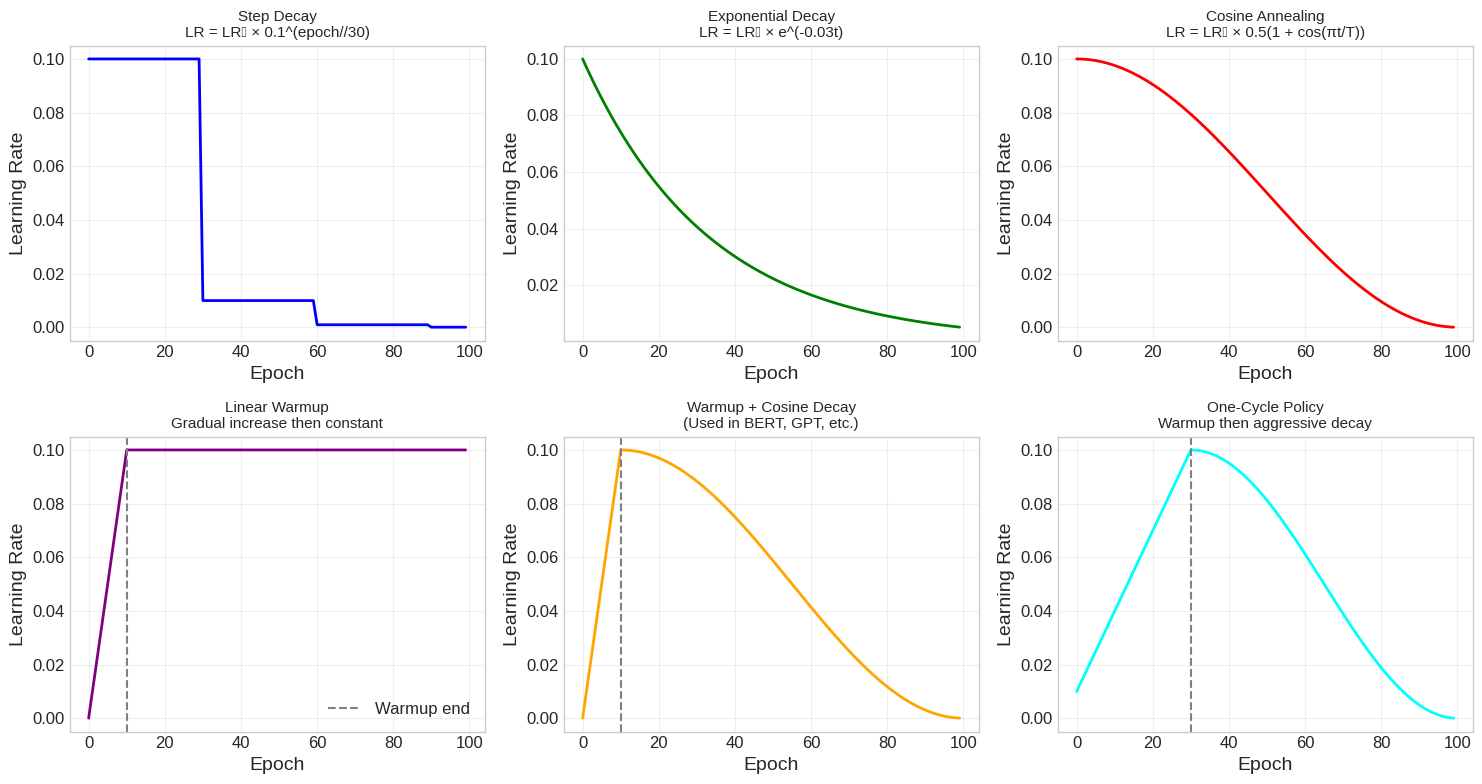


KEY INSIGHT: Learning rate schedules are crucial for good performance!
Warmup + Cosine Decay is the modern standard for transformers.


In [ ]:
# Visualize different learning rate schedules
epochs = np.arange(100)
initial_lr = 0.1

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

# 1. Step Decay
ax = axes[0, 0]
step_lr = initial_lr * (0.1 ** (epochs // 30))
ax.plot(epochs, step_lr, 'b-', linewidth=2)
ax.set_title('Step Decay\nLR = LR₀ × 0.1^(epoch//30)', fontsize=11)
ax.set_xlabel('Epoch')
ax.set_ylabel('Learning Rate')
ax.grid(True, alpha=0.3)

# 2. Exponential Decay
ax = axes[0, 1]
exp_lr = initial_lr * np.exp(-0.03 * epochs)
ax.plot(epochs, exp_lr, 'g-', linewidth=2)
ax.set_title('Exponential Decay\nLR = LR₀ × e^(-0.03t)', fontsize=11)
ax.set_xlabel('Epoch')
ax.set_ylabel('Learning Rate')
ax.grid(True, alpha=0.3)

# 3. Cosine Annealing
ax = axes[0, 2]
cosine_lr = initial_lr * 0.5 * (1 + np.cos(np.pi * epochs / 100))
ax.plot(epochs, cosine_lr, 'r-', linewidth=2)
ax.set_title('Cosine Annealing\nLR = LR₀ × 0.5(1 + cos(πt/T))', fontsize=11)
ax.set_xlabel('Epoch')
ax.set_ylabel('Learning Rate')
ax.grid(True, alpha=0.3)

# 4. Linear Warmup
ax = axes[1, 0]
warmup_epochs = 10
warmup_lr = np.where(epochs < warmup_epochs,
                     initial_lr * epochs / warmup_epochs,
                     initial_lr)
ax.plot(epochs, warmup_lr, 'purple', linewidth=2)
ax.axvline(x=warmup_epochs, color='gray', linestyle='--', label='Warmup end')
ax.set_title('Linear Warmup\nGradual increase then constant', fontsize=11)
ax.set_xlabel('Epoch')
ax.set_ylabel('Learning Rate')
ax.legend()
ax.grid(True, alpha=0.3)

# 5. Warmup + Cosine Decay (Modern Transformer Style)
ax = axes[1, 1]
warmup_epochs = 10
warmup_cosine_lr = np.where(
    epochs < warmup_epochs,
    initial_lr * epochs / warmup_epochs,
    initial_lr * 0.5 * (1 + np.cos(np.pi * (epochs - warmup_epochs) / (100 - warmup_epochs)))
)
ax.plot(epochs, warmup_cosine_lr, 'orange', linewidth=2)
ax.axvline(x=warmup_epochs, color='gray', linestyle='--')
ax.set_title('Warmup + Cosine Decay\n(Used in BERT, GPT, etc.)', fontsize=11)
ax.set_xlabel('Epoch')
ax.set_ylabel('Learning Rate')
ax.grid(True, alpha=0.3)

# 6. One-Cycle Policy
ax = axes[1, 2]
# Phase 1: warmup (30%), Phase 2: decay (70%)
phase1 = int(0.3 * 100)
phase2 = 100 - phase1
one_cycle_lr = np.concatenate([
    initial_lr * 0.1 + (initial_lr - initial_lr * 0.1) * np.arange(phase1) / phase1,  # Warmup
    initial_lr * (1 + np.cos(np.pi * np.arange(phase2) / phase2)) / 2  # Cosine decay
])
ax.plot(epochs, one_cycle_lr, 'cyan', linewidth=2)
ax.axvline(x=phase1, color='gray', linestyle='--')
ax.set_title('One-Cycle Policy\nWarmup then aggressive decay', fontsize=11)
ax.set_xlabel('Epoch')
ax.set_ylabel('Learning Rate')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("KEY INSIGHT: Learning rate schedules are crucial for good performance!")
print("Warmup + Cosine Decay is the modern standard for transformers.")
print("="*70)

---

# Part IX: Practical PyTorch Comparison

---

## 9.1 Training a Real Neural Network

Let's compare optimizers on an actual classification task using PyTorch!

We'll train the same network architecture with different optimizers and compare:
- Convergence speed
- Final accuracy
- Training stability

In [ ]:
# Create dataset
from sklearn.datasets import make_moons
import torch
import torch.nn as nn
import torch.optim as optim

# Generate moons dataset
X_np, y_np = make_moons(n_samples=1000, noise=0.2, random_state=42)
X_train = torch.FloatTensor(X_np)
y_train = torch.LongTensor(y_np)

# Create a simple neural network
class SimpleNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(2, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 2)
        )

    def forward(self, x):
        return self.layers(x)

def train_model(optimizer_class, optimizer_kwargs, epochs=100):
    """Train model with specified optimizer and return loss history."""
    torch.manual_seed(42)
    model = SimpleNet()
    optimizer = optimizer_class(model.parameters(), **optimizer_kwargs)
    criterion = nn.CrossEntropyLoss()

    losses = []
    accuracies = []

    for epoch in range(epochs):
        optimizer.zero_grad()
        outputs = model(X_train)
        loss = criterion(outputs, y_train)
        loss.backward()
        optimizer.step()

        losses.append(loss.item())
        with torch.no_grad():
            preds = outputs.argmax(dim=1)
            acc = (preds == y_train).float().mean().item()
            accuracies.append(acc)

    return losses, accuracies, model

# Train with different optimizers
optimizers_pytorch = {
    'SGD (lr=0.1)': (optim.SGD, {'lr': 0.1}),
    'SGD+Momentum': (optim.SGD, {'lr': 0.1, 'momentum': 0.9}),
    'Adam (lr=0.01)': (optim.Adam, {'lr': 0.01}),
    'AdamW (lr=0.01)': (optim.AdamW, {'lr': 0.01, 'weight_decay': 0.01}),
    'RMSprop (lr=0.01)': (optim.RMSprop, {'lr': 0.01}),
}

results = {}
for name, (opt_class, opt_kwargs) in optimizers_pytorch.items():
    losses, accuracies, model = train_model(opt_class, opt_kwargs, epochs=100)
    results[name] = {'losses': losses, 'accuracies': accuracies, 'model': model}
    print(f"{name}: Final Loss = {losses[-1]:.4f}, Final Acc = {accuracies[-1]:.2%}")

SGD (lr=0.1): Final Loss = 0.2686, Final Acc = 88.10%
SGD+Momentum: Final Loss = 0.0663, Final Acc = 97.40%
Adam (lr=0.01): Final Loss = 0.0538, Final Acc = 98.10%
AdamW (lr=0.01): Final Loss = 0.0545, Final Acc = 98.10%
RMSprop (lr=0.01): Final Loss = 0.0655, Final Acc = 97.00%


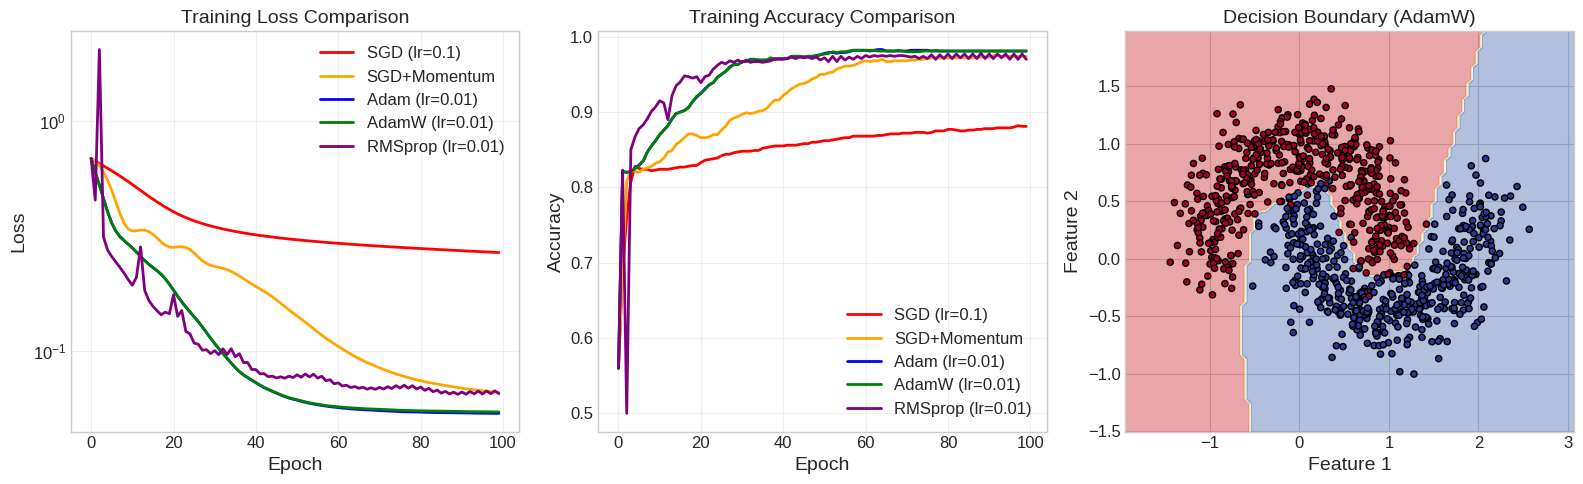


OBSERVATION: Adam and AdamW typically converge faster than SGD!
But SGD+Momentum can achieve similar results with proper tuning.


In [ ]:
# Visualize results
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
colors = ['red', 'orange', 'blue', 'green', 'purple']

# Plot 1: Loss curves
ax = axes[0]
for (name, data), color in zip(results.items(), colors):
    ax.plot(data['losses'], label=name, color=color, linewidth=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('Training Loss Comparison', fontsize=14)
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_yscale('log')

# Plot 2: Accuracy curves
ax = axes[1]
for (name, data), color in zip(results.items(), colors):
    ax.plot(data['accuracies'], label=name, color=color, linewidth=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('Accuracy')
ax.set_title('Training Accuracy Comparison', fontsize=14)
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 3: Decision boundaries (for AdamW)
ax = axes[2]
# Create mesh grid for decision boundary
x_min, x_max = X_np[:, 0].min() - 0.5, X_np[:, 0].max() + 0.5
y_min, y_max = X_np[:, 1].min() - 0.5, X_np[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                     np.linspace(y_min, y_max, 100))
grid = torch.FloatTensor(np.c_[xx.ravel(), yy.ravel()])

# Get predictions from AdamW model
model = results['AdamW (lr=0.01)']['model']
model.eval()
with torch.no_grad():
    Z = model(grid).argmax(dim=1).numpy().reshape(xx.shape)

ax.contourf(xx, yy, Z, alpha=0.4, cmap='RdYlBu')
ax.scatter(X_np[:, 0], X_np[:, 1], c=y_np, cmap='RdYlBu', edgecolor='black', s=20)
ax.set_xlabel('Feature 1')
ax.set_ylabel('Feature 2')
ax.set_title('Decision Boundary (AdamW)', fontsize=14)

plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("OBSERVATION: Adam and AdamW typically converge faster than SGD!")
print("But SGD+Momentum can achieve similar results with proper tuning.")
print("="*70)

## 9.2 Which Optimizer Should You Use?

### Quick Decision Guide

```
                    START HERE
                        │
                        ▼
        ┌───────────────────────────────┐
        │  Are you fine-tuning a        │
        │  pre-trained model?           │
        └───────────────────────────────┘
                   │
          ┌───────┴───────┐
         YES              NO
          │               │
          ▼               ▼
    ┌─────────────┐   ┌─────────────────────┐
    │   AdamW     │   │ Computer Vision?    │
    │ (lr=1e-5)   │   │ (CNN, ViT)          │
    └─────────────┘   └─────────────────────┘
                              │
                     ┌───────┴───────┐
                    YES              NO
                     │               │
                     ▼               ▼
              ┌───────────┐   ┌─────────────┐
              │ SGD+Mom   │   │    AdamW    │
              │ (lr=0.1)  │   │  (lr=1e-4)  │
              └───────────┘   └─────────────┘
```

### Recommendations by Task

| Task | Optimizer | Learning Rate | Notes |
|------|-----------|---------------|-------|
| **CNNs (ResNet, etc.)** | SGD + Momentum | 0.1 with step decay | Best final accuracy |
| **Transformers (NLP)** | AdamW | 1e-4 with warmup | Standard practice |
| **Vision Transformers** | AdamW | 1e-4 with warmup | Or SAM for better generalization |
| **GANs** | Adam | 1e-4 to 2e-4 | β₁=0.5 often works better |
| **Fine-tuning** | AdamW | 1e-5 to 5e-5 | Very small LR! |
| **Quick experiments** | Adam | 1e-3 | Fast convergence, good baseline |

---

# Part X: Modern & Advanced Optimizers

---

## 10.1 Beyond Adam: Cutting-Edge Optimizers

### SAM (Sharpness-Aware Minimization)

**Key Insight**: Flat minima generalize better than sharp minima!

SAM seeks parameters that lie in "flat" regions of the loss landscape:
1. First, find the worst-case perturbation within a ball
2. Then, minimize the loss at that worst-case point

```python
# Conceptual SAM step
# 1. Compute gradient at current point
grad = compute_gradient(w)
# 2. Move to worst-case point in ε-ball
w_adv = w + rho * grad / grad.norm()
# 3. Compute gradient at adversarial point
grad_adv = compute_gradient(w_adv)
# 4. Update using adversarial gradient
w = w - lr * grad_adv
```

**Benefits**: Better generalization, especially for Vision Transformers!

### Lion (EvoLved Sign Momentum)

Discovered by Google using **neural architecture search for optimizers**!

Key differences from Adam:
- Uses **sign of momentum** instead of magnitude
- Simpler and more memory-efficient
- Often works better with larger batch sizes

### LARS / LAMB (Layer-wise Adaptive Rate Scaling)

Designed for **very large batch training** (e.g., batch size 32K+):
- Computes per-layer learning rate scaling
- Enables training large models in less time
- Used for training BERT in 76 minutes!

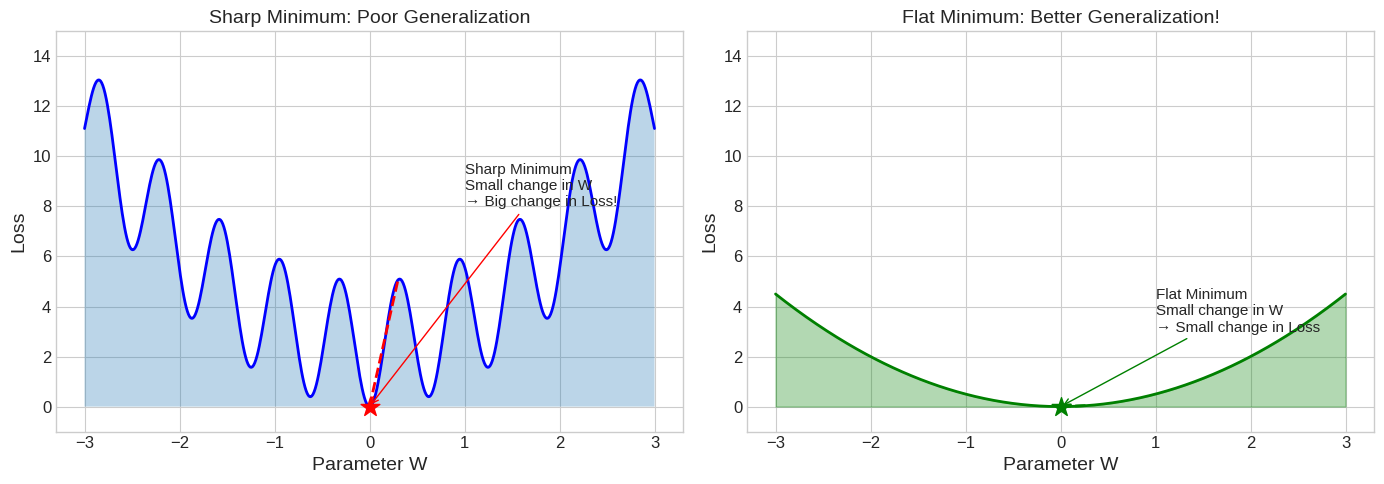


SAM INSIGHT: Flat minima are more robust to perturbations!
This means better generalization to unseen data.


In [ ]:
# Visualize sharp vs flat minima (why SAM works)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x = np.linspace(-3, 3, 500)

# Sharp minimum
ax = axes[0]
y_sharp = x**2 + 5*np.sin(5*x)**2  # Many narrow valleys
ax.plot(x, y_sharp, 'b-', linewidth=2)
ax.fill_between(x, y_sharp, alpha=0.3)
# Highlight a sharp minimum
ax.scatter([0], [0], color='red', s=200, zorder=5, marker='*')
ax.annotate('Sharp Minimum\nSmall change in W\n→ Big change in Loss!',
            xy=(0, 0), xytext=(1, 8),
            fontsize=11, arrowprops=dict(arrowstyle='->', color='red'))
# Show perturbation effect
ax.plot([0, 0.3], [0, 0.3**2 + 5*np.sin(5*0.3)**2], 'r--', linewidth=2)
ax.set_xlabel('Parameter W')
ax.set_ylabel('Loss')
ax.set_title('Sharp Minimum: Poor Generalization', fontsize=14)
ax.set_ylim(-1, 15)

# Flat minimum
ax = axes[1]
y_flat = 0.5*x**2  # Smooth, flat valley
ax.plot(x, y_flat, 'g-', linewidth=2)
ax.fill_between(x, y_flat, alpha=0.3, color='green')
ax.scatter([0], [0], color='green', s=200, zorder=5, marker='*')
ax.annotate('Flat Minimum\nSmall change in W\n→ Small change in Loss',
            xy=(0, 0), xytext=(1, 3),
            fontsize=11, arrowprops=dict(arrowstyle='->', color='green'))
# Show perturbation effect
ax.plot([0, 0.3], [0, 0.5*0.3**2], 'g--', linewidth=2)
ax.set_xlabel('Parameter W')
ax.set_ylabel('Loss')
ax.set_title('Flat Minimum: Better Generalization!', fontsize=14)
ax.set_ylim(-1, 15)

plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("SAM INSIGHT: Flat minima are more robust to perturbations!")
print("This means better generalization to unseen data.")
print("="*70)

## 10.2 The Optimizer Evolution Timeline

```
1847  ─────  Gradient Descent (Cauchy)
              │
1964  ─────  Stochastic Gradient Descent
              │
1983  ─────  Momentum (Polyak)
              │
2011  ─────  AdaGrad (Duchi et al.)
              │
2012  ─────  RMSprop (Hinton, unpublished)
              │
2014  ─────  Adam (Kingma & Ba)
              │
2017  ─────  AdamW (Loshchilov & Hutter)
              │
2020  ─────  SAM (Foret et al.)
              │
2023  ─────  Lion (Chen et al., Google)
              │
  ?   ─────  Your contribution? 🚀
```

---

# Summary: Key Takeaways

---

## What We Learned

1. **Gradient Descent** is the foundation - we move opposite to the gradient to minimize loss

2. **SGD** adds stochasticity that helps escape local minima and enables large-scale training

3. **Momentum** adds "physics" to optimization, dampening oscillations and accelerating convergence

4. **Adaptive methods** (AdaGrad, RMSprop) automatically adjust learning rates per parameter

5. **Adam** combines momentum + adaptive learning rates = robust default choice

6. **AdamW** fixes weight decay in Adam = modern standard for transformers

7. **Learning rate schedules** (warmup + decay) are crucial for optimal performance

8. **Modern optimizers** (SAM, Lion) push the boundaries of what's possible

## The Optimizer Hierarchy

```
Simplest ──────────────────────────────────────────────► Most Sophisticated

  GD  →  SGD  →  SGD+Momentum  →  RMSprop  →  Adam  →  AdamW  →  SAM/Lion
  │       │          │              │          │         │          │
  │       │          │              │          │         │          │
 Basic  Noise     Physics       Adaptive    Both!    Proper     Flat
 idea   helps     intuition    per-param   combined  weight    minima
                                                     decay

```

## Final Recommendations

| If you're... | Use this | Why |
|--------------|----------|-----|
| Just starting out | Adam | Works well out of the box |
| Training transformers | AdamW + warmup | Industry standard |
| Training CNNs | SGD + Momentum | Often best accuracy |
| Want best generalization | SAM | Finds flat minima |
| Memory constrained | Lion or SGD | Lower memory usage |

**Remember**: The optimizer is just one piece - also tune learning rate, batch size, and schedule!

---

## Congratulations! 🎉

You now understand optimizers from zero to hero! You can:
- Explain why gradient descent works
- Debug training issues related to optimization
- Choose the right optimizer for your task
- Understand cutting-edge research in optimization

**Next Steps**:
- Implement these optimizers yourself
- Experiment with different optimizers on your projects
- Read the original papers for deeper understanding